# Импорт библиотек

In [1]:
# %pip install catboost
# %pip install ipywidgets
# %pip install nbformat

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
from catboost import CatBoostClassifier, Pool
from metric import precision_at_recall
import optuna
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score


sns.set_theme(style='whitegrid', font='sans-serif')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import warnings
warnings.filterwarnings(
    'ignore', 
    category=UserWarning
)


In [3]:
train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean())
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0810567126498963


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [4]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [5]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 328905 entries, 0 to 328904
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   cookie_id      328905 non-null  str           
 1   event_ts       328905 non-null  datetime64[us]
 2   eid            328905 non-null  int64         
 3   event_name     328905 non-null  str           
 4   platform       328905 non-null  str           
 5   user_agent     328905 non-null  str           
 6   item_id        214308 non-null  float64       
 7   item_category  295985 non-null  str           
 8   item_location  305112 non-null  str           
 9   seller_type    195052 non-null  str           
 10  search_query   100402 non-null  str           
 11  search_page    100402 non-null  float64       
 12  pointer_x      108540 non-null  float64       
 13  pointer_y      108540 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(8)
memory usage

In [6]:
events.shape

(328905, 14)

# Чистка и EDA датасета

Отбираем нужные по окну события

In [7]:
def events_in_window(events, meta):
    col = ['cookie_id', 'window_start_ts', 'window_end_ts', 'cookie_created_at']
    if "target" in meta.columns:
        col.append("target")
    ev = events.merge(meta[col], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print(len(ev_tr), len(ev_te))

198436 89690


In [8]:
X = ev_tr.copy()
X.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,window_start_ts,window_end_ts,cookie_created_at,target
0,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0,2026-04-13,2026-04-14,2025-12-16 02:45:12,0
1,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN,2026-04-08,2026-04-09,2025-12-27 17:38:36,0
2,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN,2026-04-12,2026-04-13,2026-04-10 06:13:58,0
4,ck_f80d85f038cdacee,2026-04-11 16:08:12,200,item_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1000845.0,bytovaya_tehnika,sankt-peterburg,private,NaN,NaN,NaN,NaN,2026-04-11,2026-04-12,2025-08-23 19:05:01,0
5,ck_e4f046f721d10f81,2026-04-10 16:50:05,200,item_view,IOS,Mozilla/5.0 (iPhone; CPU iPhone OS 15_2 like M...,1055188.0,telefony,ekaterinburg,pro,NaN,NaN,NaN,NaN,2026-04-10,2026-04-11,2026-04-08 17:40:46,0


In [9]:
X.shape

(198436, 18)

In [10]:
desired_columns = ['cookie_id', 'cookie_created_at', 'window_start_ts', 'event_ts', 'window_end_ts', 'eid', 'event_name', 'platform', 'user_agent',
       'item_id', 'item_category', 'item_location', 'seller_type',
       'search_query', 'search_page', 'pointer_x', 'pointer_y', 'target']

X = X[desired_columns]

Убирем колонку event_name - запомним какой код чему следует, дальше пригодится

In [11]:
dict_eid_to_event_name = X.groupby('eid')['event_name'].first().to_dict()
dict_eid_to_event_name

{100: 'search_results_view',
 200: 'item_view',
 210: 'photo_swipe',
 220: 'seller_page_view',
 300: 'contact_phone_show',
 301: 'contact_chat_open',
 303: 'contact_message_sent',
 400: 'favorite_add',
 500: 'login'}

In [12]:
X = X.drop(columns=['event_name'])

В поле platform много повторяющихся по смыслу типов, но разному написанных - приведем к одним типам

In [13]:
X['platform'].unique()

<StringArray>
[    'WEB',     'web', 'desktop',     'IOS',     'Web', 'android', 'Android',
 'ANDROID',     'ios',     'iOS',  'iphone']
Length: 11, dtype: str

In [14]:
X['platform'] = X['platform'].str.lower()
X.loc[X['platform'] == 'iphone', 'platform'] = 'ios'

Удаляем дубликаты и создаем признак сколько дубликатов было(гипотеза: бот отправляет запросы с какой-то периодичностью, а человек при зависании может много раз кликать или нажимать на какую-то кнопку)

In [15]:
is_duplicate = X.duplicated(keep='first')
X['cnt_duplicate'] = is_duplicate.groupby(X['cookie_id']).transform('sum')
X = X.drop_duplicates().reset_index(drop=True)

Посмотрим где есть пропуски и сколько их

In [16]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 195482 entries, 0 to 195481
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   cookie_id          195482 non-null  str           
 1   cookie_created_at  195482 non-null  datetime64[us]
 2   window_start_ts    195482 non-null  datetime64[us]
 3   event_ts           195482 non-null  datetime64[us]
 4   window_end_ts      195482 non-null  datetime64[us]
 5   eid                195482 non-null  int64         
 6   platform           195482 non-null  str           
 7   user_agent         195482 non-null  str           
 8   item_id            130829 non-null  float64       
 9   item_category      180083 non-null  str           
 10  item_location      185792 non-null  str           
 11  seller_type        118966 non-null  str           
 12  search_query       60806 non-null   str           
 13  search_page        60806 non-null   float64       
 14 

In [17]:
for col in X.columns:
    print(col)
    print(X[col].describe())
    print()

cookie_id
count                  195482
unique                  11091
top       ck_71bf885006274d6a
freq                      165
Name: cookie_id, dtype: object

cookie_created_at
count                        195482
mean     2026-01-31 19:36:42.432366
min             2025-01-22 17:09:47
25%             2025-12-25 01:53:28
50%             2026-02-13 06:05:06
75%             2026-04-04 19:17:55
max             2026-04-18 22:45:04
Name: cookie_created_at, dtype: object

window_start_ts
count                        195482
mean     2026-04-12 05:48:50.614583
min             2026-04-06 00:00:00
25%             2026-04-09 00:00:00
50%             2026-04-12 00:00:00
75%             2026-04-15 00:00:00
max             2026-04-19 00:00:00
Name: window_start_ts, dtype: object

event_ts
count                        195482
mean     2026-04-12 19:57:39.619657
min             2026-04-06 00:02:57
25%      2026-04-09 14:58:19.250000
50%      2026-04-12 16:16:32.500000
75%      2026-04-15 22:40:59.7500

## Графики распределение таргета в колонках с пропусками
Посмотрим как влияет пропуск в данных на таргет

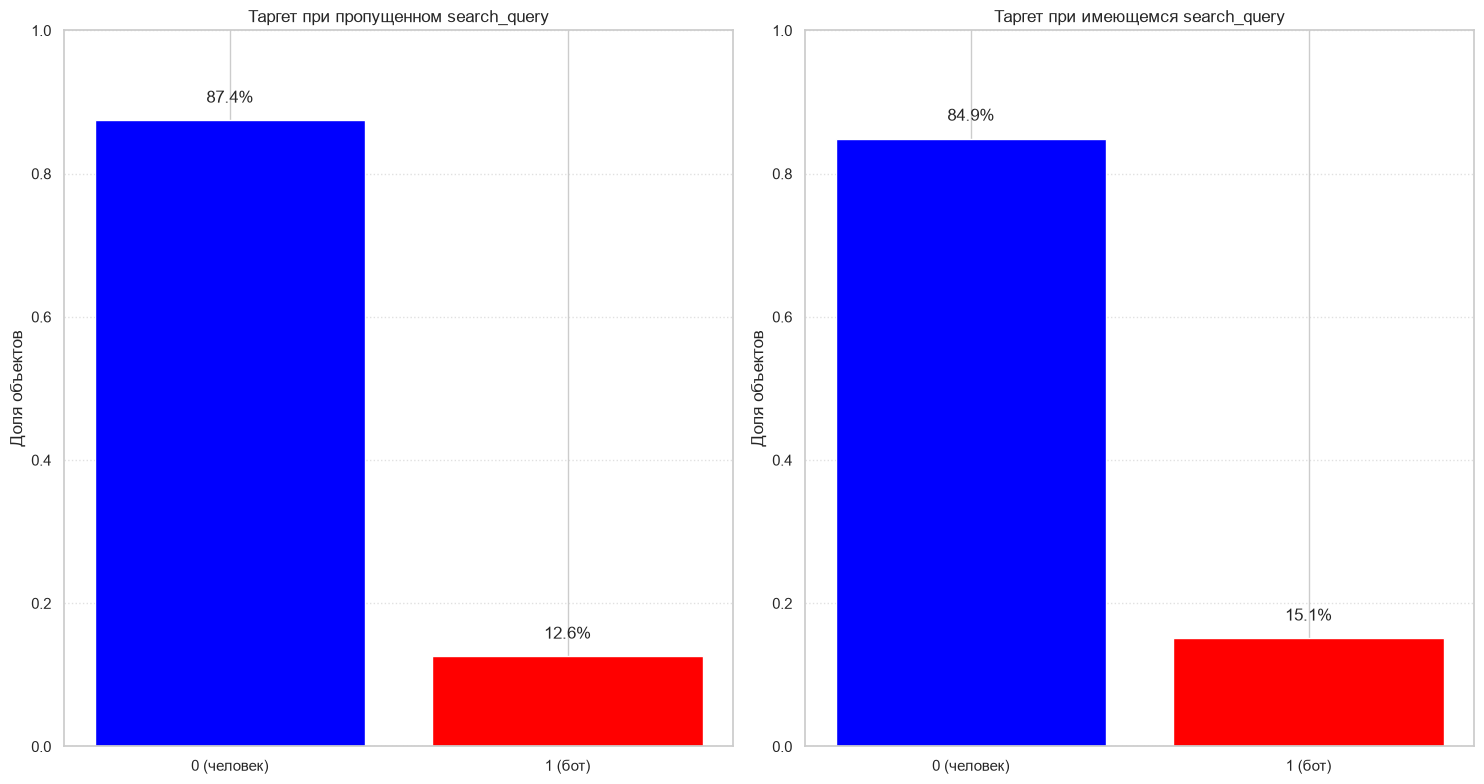

In [18]:
data_isna = X[X['search_query'].isna()]['target'].value_counts(normalize=True).sort_index()
data_isnotna = X[X['search_query'].notna()]['target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
bars_isna = ax[0].bar(['0 (человек)', '1 (бот)'], data_isna.values, color=['blue', 'red'])
bars_notna = ax[1].bar(['0 (человек)', '1 (бот)'], data_isnotna.values, color=['blue', 'red'])

for bar in bars_isna:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')
for bar in bars_notna:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')

ax[0].set_title('Таргет при пропущенном search_query')
ax[0].set_ylabel('Доля объектов')
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', linestyle=':', alpha=0.6)

ax[1].set_title('Таргет при имеющемся search_query')
ax[1].set_ylabel('Доля объектов')
ax[1].set_ylim(0, 1)
ax[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

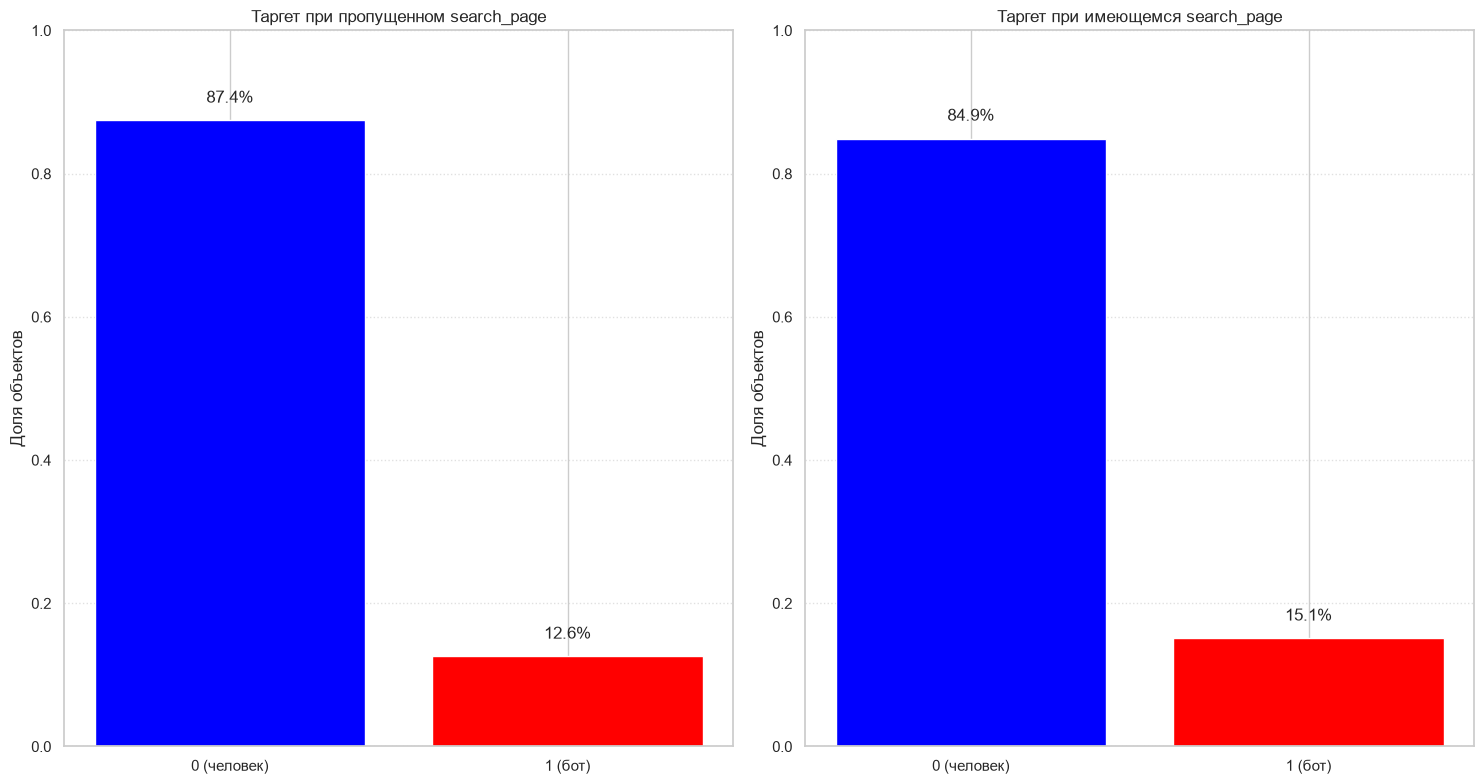

In [19]:
data_isna = X[X['search_page'].isna()]['target'].value_counts(normalize=True).sort_index()
data_isnotna = X[X['search_page'].notna()]['target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
bars_isna = ax[0].bar(['0 (человек)', '1 (бот)'], data_isna.values, color=['blue', 'red'])
bars_notna = ax[1].bar(['0 (человек)', '1 (бот)'], data_isnotna.values, color=['blue', 'red'])

for bar in bars_isna:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')
for bar in bars_notna:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')

ax[0].set_title('Таргет при пропущенном search_page')
ax[0].set_ylabel('Доля объектов')
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', linestyle=':', alpha=0.6)

ax[1].set_title('Таргет при имеющемся search_page')
ax[1].set_ylabel('Доля объектов')
ax[1].set_ylim(0, 1)
ax[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

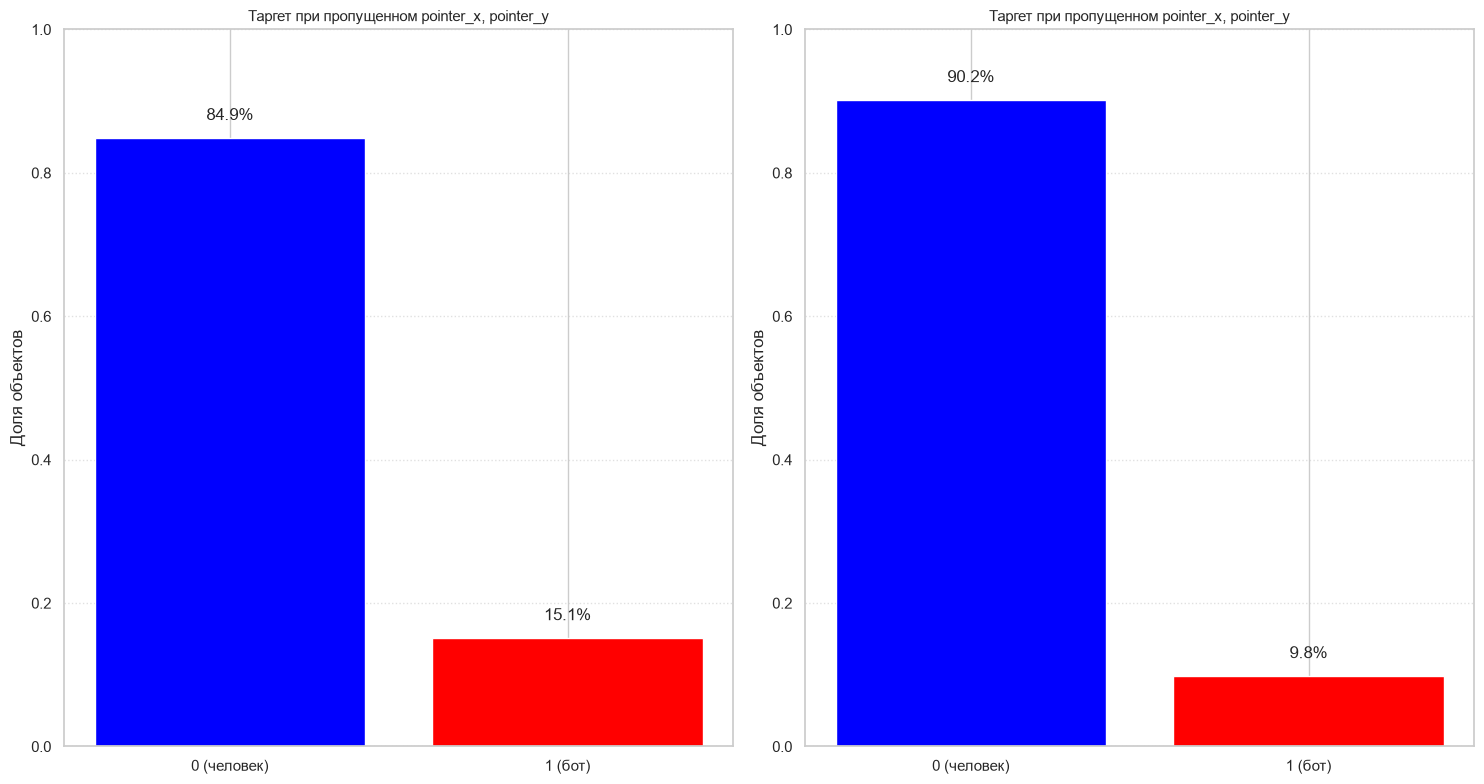

In [20]:
data_isna = X[X['pointer_x'].isna()]['target'].value_counts(normalize=True).sort_index()
data_isnotna = X[X['pointer_x'].notna()]['target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
bars_isna = ax[0].bar(['0 (человек)', '1 (бот)'], data_isna.values, color=['blue', 'red'])
bars_notna = ax[1].bar(['0 (человек)', '1 (бот)'], data_isnotna.values, color=['blue', 'red'])

for bar in bars_isna:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')
for bar in bars_notna:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')

ax[0].set_title('Таргет при пропущенном pointer_x, pointer_y', fontsize=11)
ax[0].set_ylabel('Доля объектов')
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', linestyle=':', alpha=0.6)

ax[1].set_title('Таргет при пропущенном pointer_x, pointer_y', fontsize=11)
ax[1].set_ylabel('Доля объектов')
ax[1].set_ylim(0, 1)
ax[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

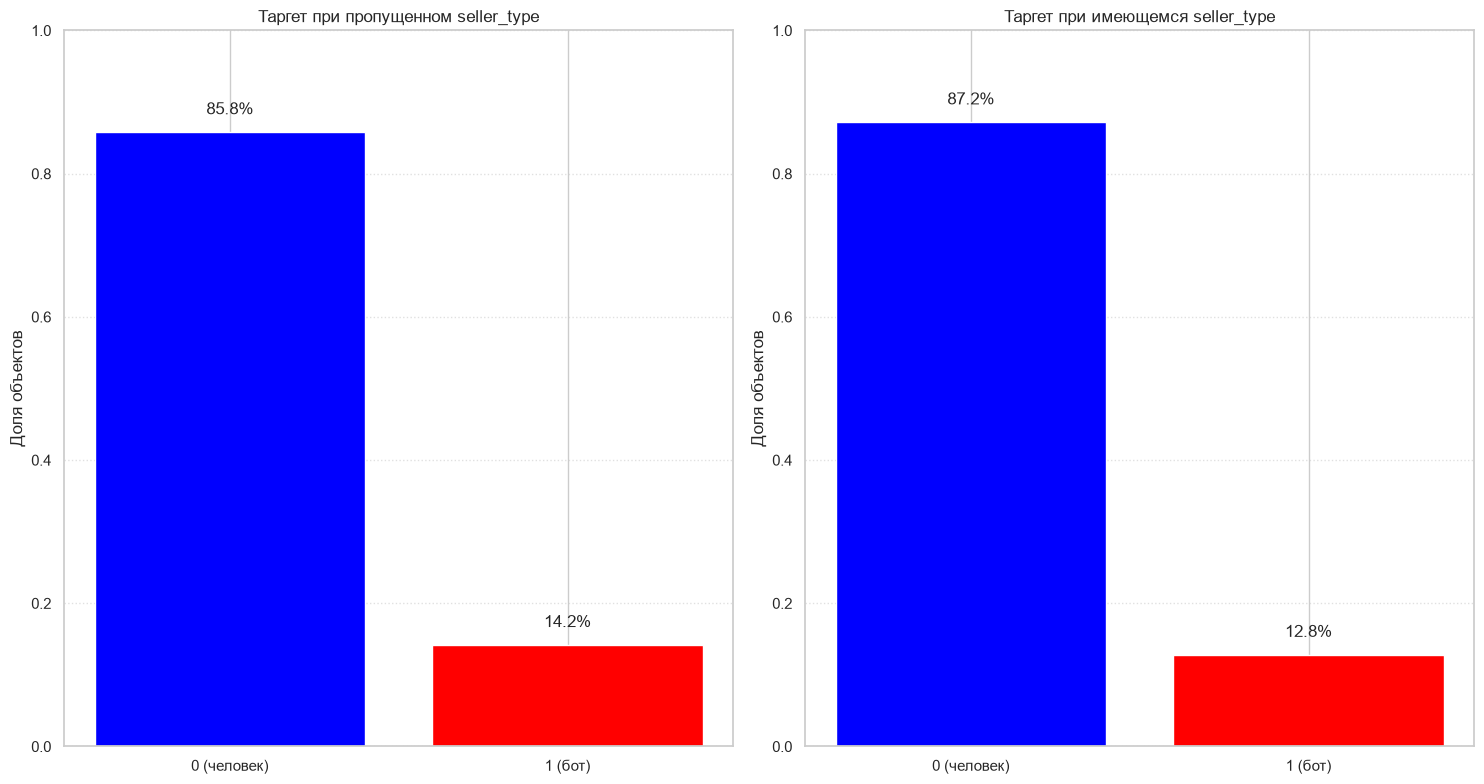

In [21]:
data_isna = X[X['seller_type'].isna()]['target'].value_counts(normalize=True).sort_index()
data_isnotna = X[X['seller_type'].notna()]['target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
bars_isna = ax[0].bar(['0 (человек)', '1 (бот)'], data_isna.values, color=['blue', 'red'])
bars_notna = ax[1].bar(['0 (человек)', '1 (бот)'], data_isnotna.values, color=['blue', 'red'])

for bar in bars_isna:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')
for bar in bars_notna:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')

ax[0].set_title('Таргет при пропущенном seller_type')
ax[0].set_ylabel('Доля объектов')
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', linestyle=':', alpha=0.6)

ax[1].set_title('Таргет при имеющемся seller_type')
ax[1].set_ylabel('Доля объектов')
ax[1].set_ylim(0, 1)
ax[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

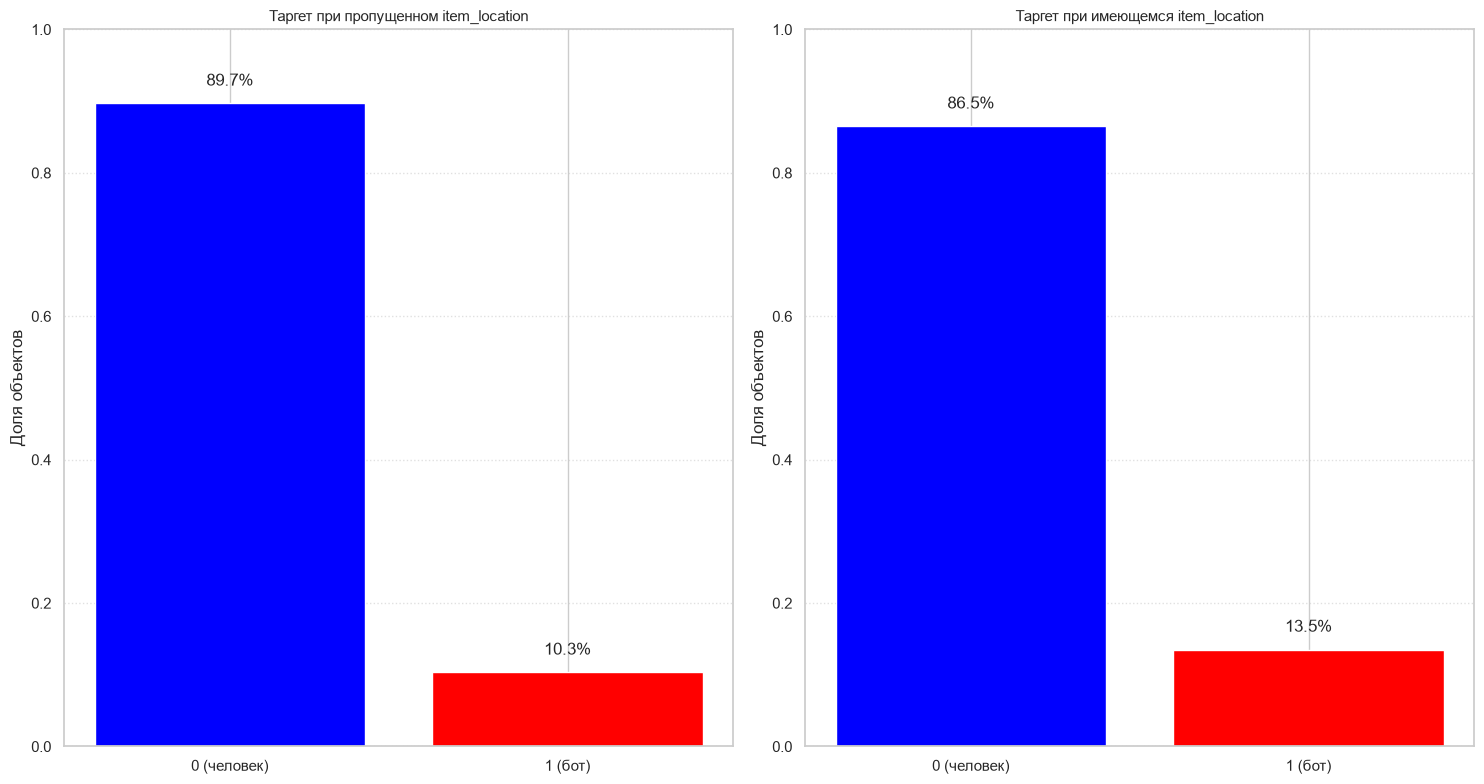

In [22]:
data_isna = X[X['item_location'].isna()]['target'].value_counts(normalize=True).sort_index()
data_isnotna = X[X['item_location'].notna()]['target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
bars_isna = ax[0].bar(['0 (человек)', '1 (бот)'], data_isna.values, color=['blue', 'red'])
bars_notna = ax[1].bar(['0 (человек)', '1 (бот)'], data_isnotna.values, color=['blue', 'red'])

for bar in bars_isna:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')
for bar in bars_notna:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')

ax[0].set_title('Таргет при пропущенном item_location', fontsize=11)
ax[0].set_ylabel('Доля объектов')
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', linestyle=':', alpha=0.6)

ax[1].set_title('Таргет при имеющемся item_location', fontsize=11)
ax[1].set_ylabel('Доля объектов')
ax[1].set_ylim(0, 1)
ax[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

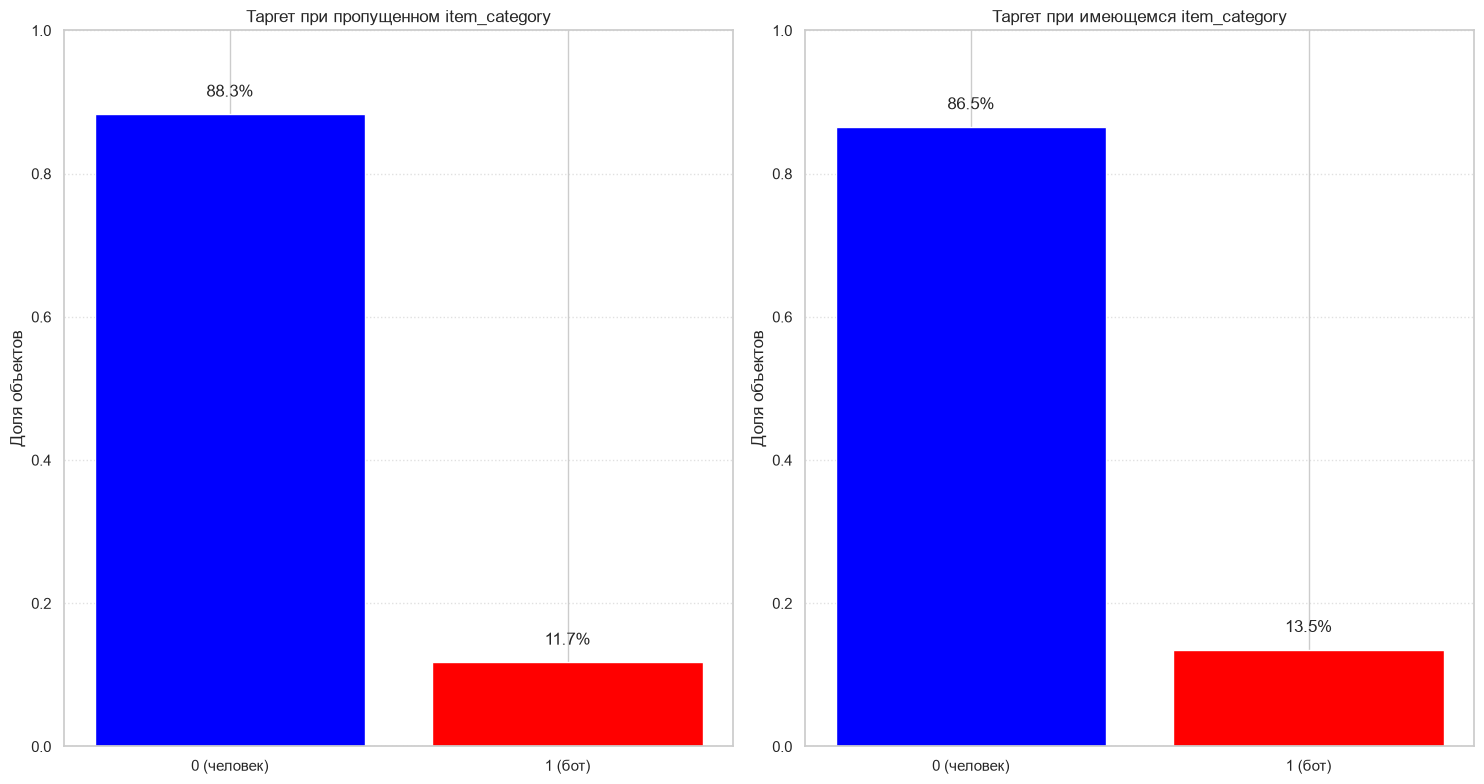

In [23]:
data_isna = X[X['item_category'].isna()]['target'].value_counts(normalize=True).sort_index()
data_isnotna = X[X['item_category'].notna()]['target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
bars_isna = ax[0].bar(['0 (человек)', '1 (бот)'], data_isna.values, color=['blue', 'red'])
bars_notna = ax[1].bar(['0 (человек)', '1 (бот)'], data_isnotna.values, color=['blue', 'red'])

for bar in bars_isna:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')
for bar in bars_notna:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')

ax[0].set_title('Таргет при пропущенном item_category')
ax[0].set_ylabel('Доля объектов')
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', linestyle=':', alpha=0.6)

ax[1].set_title('Таргет при имеющемся item_category')
ax[1].set_ylabel('Доля объектов')
ax[1].set_ylim(0, 1)
ax[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

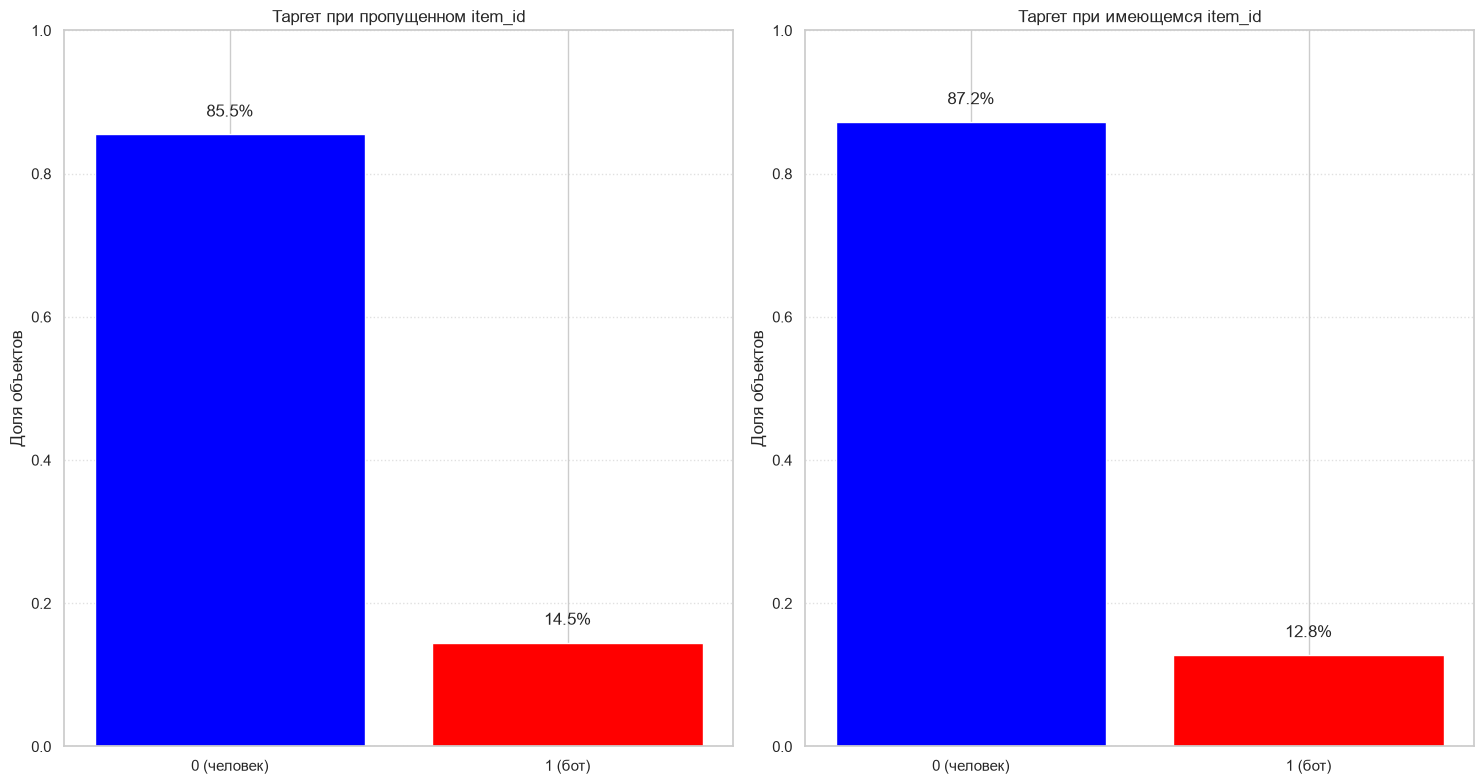

In [24]:
data_isna = X[X['item_id'].isna()]['target'].value_counts(normalize=True).sort_index()
data_isnotna = X[X['item_id'].notna()]['target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
bars_isna = ax[0].bar(['0 (человек)', '1 (бот)'], data_isna.values, color=['blue', 'red'])
bars_notna = ax[1].bar(['0 (человек)', '1 (бот)'], data_isnotna.values, color=['blue', 'red'])

for bar in bars_isna:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')
for bar in bars_notna:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom')

ax[0].set_title('Таргет при пропущенном item_id')
ax[0].set_ylabel('Доля объектов')
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', linestyle=':', alpha=0.6)

ax[1].set_title('Таргет при имеющемся item_id')
ax[1].set_ylabel('Доля объектов')
ax[1].set_ylim(0, 1)
ax[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Исходя из графиков появляется идея сделать по два стоблца вида: is_nan - 1, 0, если 0, то в колонке оставляем значение, если нет, то 0 или пустую строку

## Графики распределения таргета в зависимости от платформы

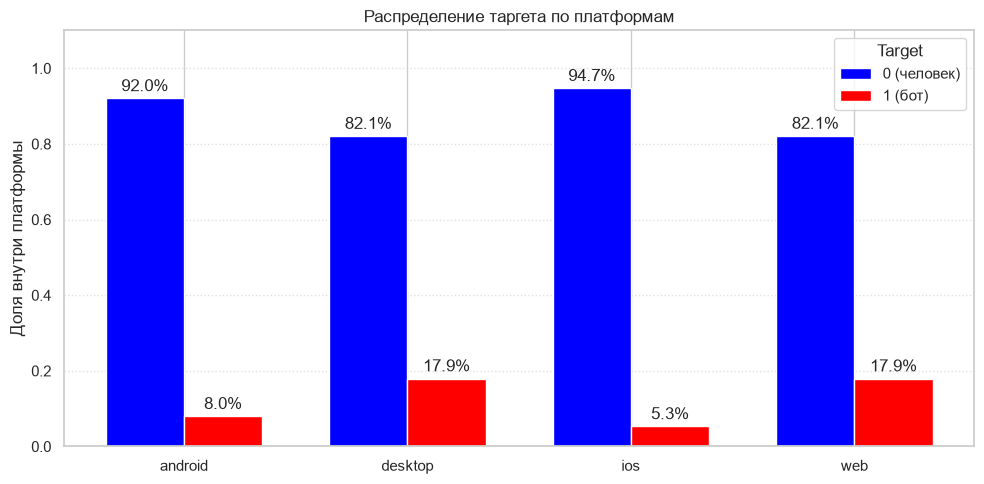

In [25]:
platform_target = X.groupby('platform')['target'].value_counts(normalize=True).unstack(fill_value=0).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

x_labels = platform_target.index
x_indices = range(len(x_labels))
width = 0.35

bars_0 = ax.bar([i - width/2 for i in x_indices], platform_target[0], width=width, label='0 (человек)', color='blue')
bars_1 = ax.bar([i + width/2 for i in x_indices], platform_target[1], width=width, label='1 (бот)', color='red')

for bar in bars_0:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.1%}', ha='center', va='bottom')

for bar in bars_1:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.1%}', ha='center', va='bottom')

ax.set_xticks(x_indices)
ax.set_xticklabels(x_labels)
ax.set_title('Распределение таргета по платформам')
ax.set_ylabel('Доля внутри платформы')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(title='Target')

plt.tight_layout()
plt.show()

Можем соединить desktop\web так как они идентичны

In [26]:
X.loc[X['platform'] == 'desktop', 'platform'] = 'web'

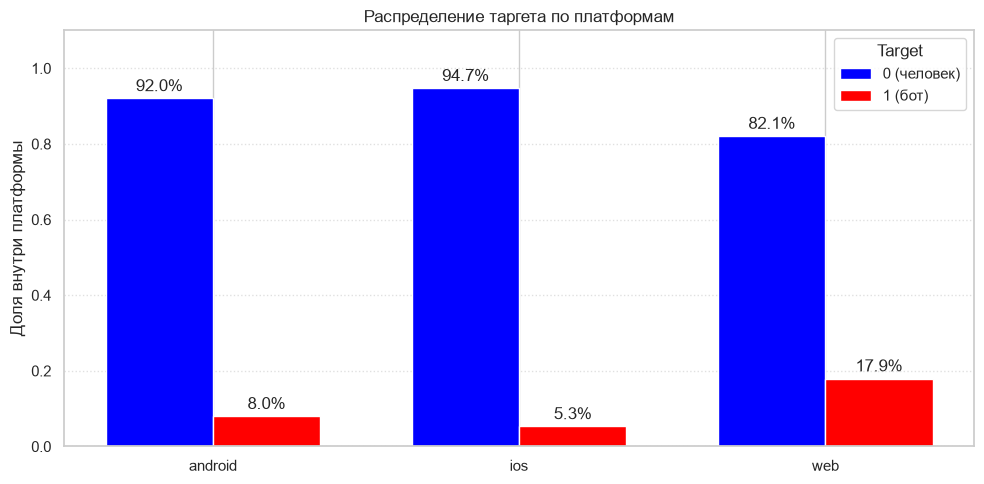

In [27]:
platform_target = X.groupby('platform')['target'].value_counts(normalize=True).unstack(fill_value=0).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

x_labels = platform_target.index
x_indices = range(len(x_labels))
width = 0.35

bars_0 = ax.bar([i - width/2 for i in x_indices], platform_target[0], width=width, label='0 (человек)', color='blue')
bars_1 = ax.bar([i + width/2 for i in x_indices], platform_target[1], width=width, label='1 (бот)', color='red')

for bar in bars_0:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.1%}', ha='center', va='bottom')

for bar in bars_1:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.1%}', ha='center', va='bottom')

ax.set_xticks(x_indices)
ax.set_xticklabels(x_labels)
ax.set_title('Распределение таргета по платформам')
ax.set_ylabel('Доля внутри платформы')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(title='Target')

plt.tight_layout()
plt.show()

## График распределения таргета в зависимости от user_agenta

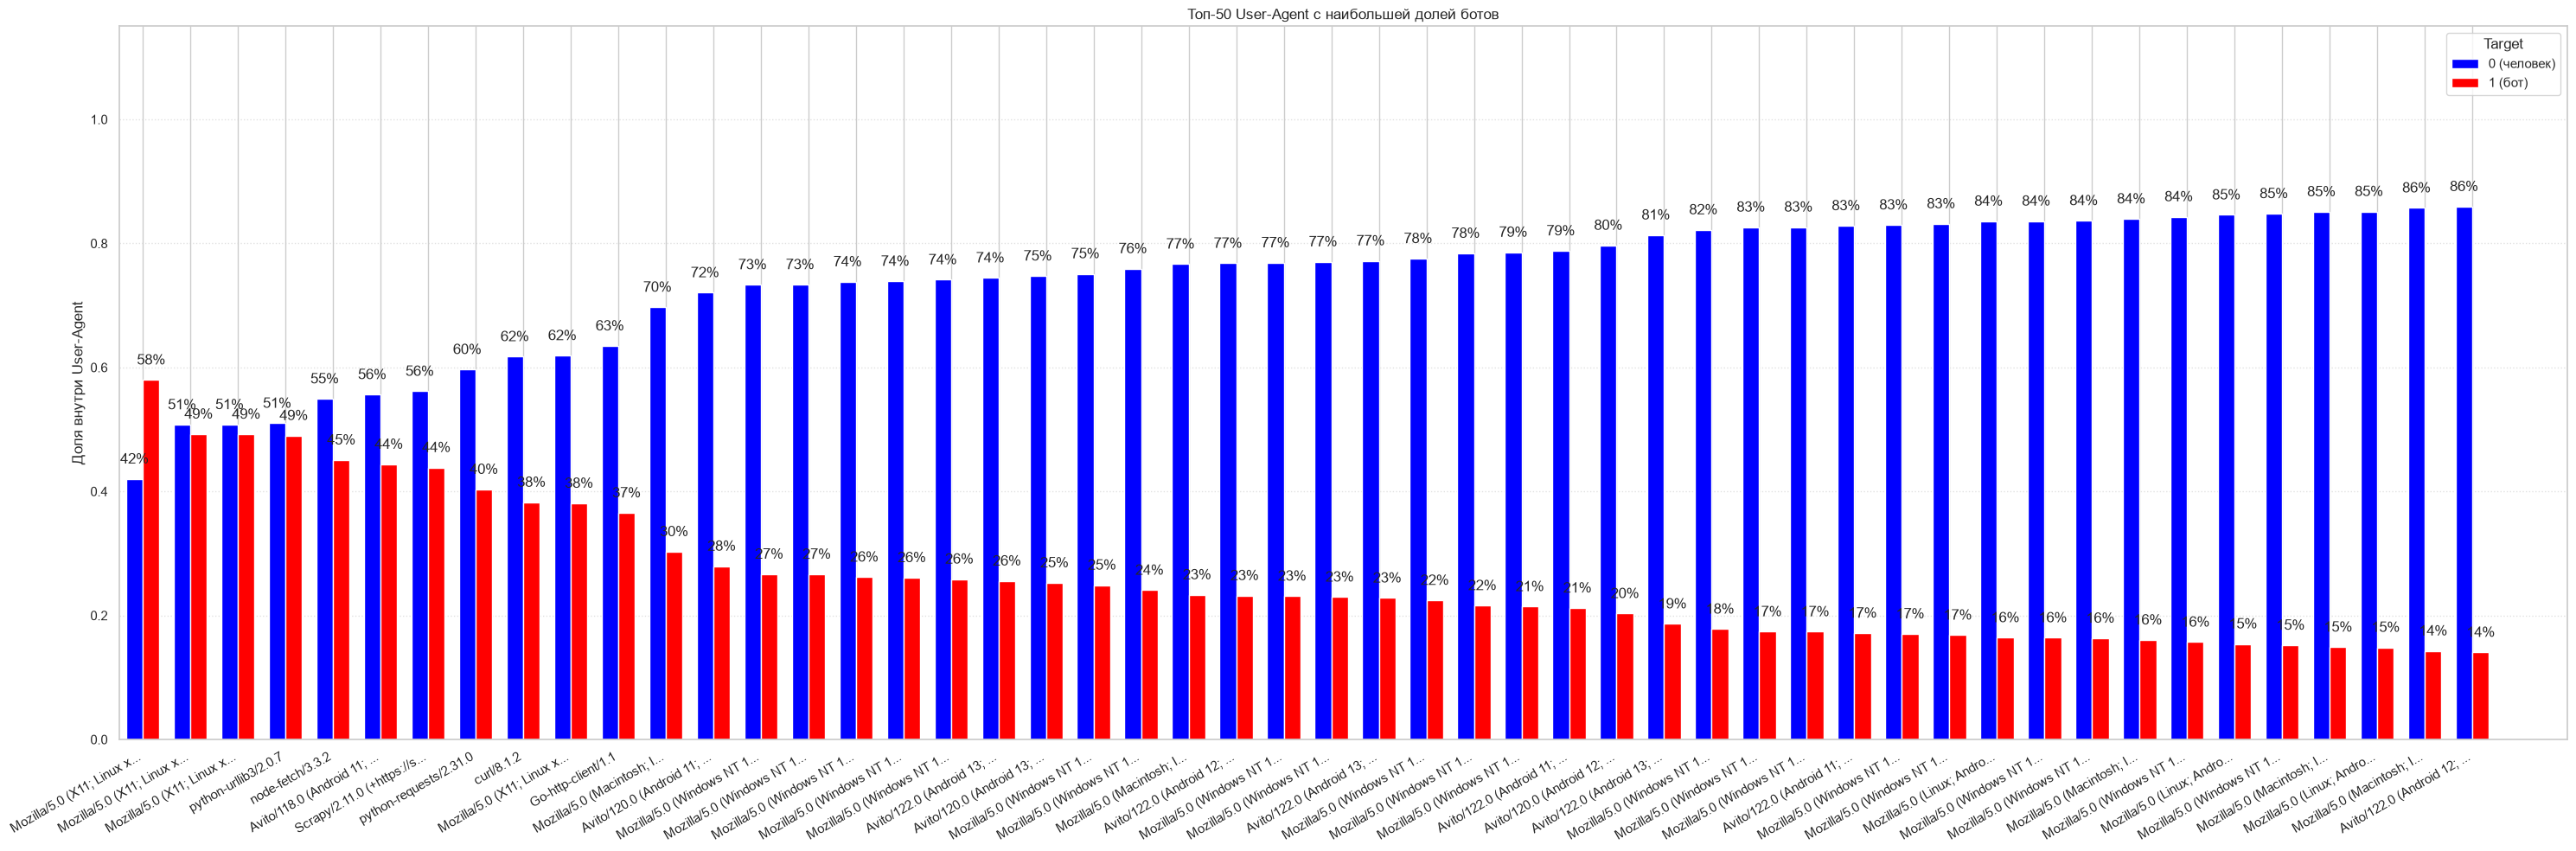

In [28]:
ua_bot_stats = X.groupby('user_agent')['target'].value_counts(normalize=True).unstack(fill_value=0)
top_bot_ua = ua_bot_stats.sort_values(by=1, ascending=False).head(50)
labels = [str(ua)[:25] + '...' if len(str(ua)) > 25 else str(ua) for ua in top_bot_ua.index]

fig, ax = plt.subplots(figsize=(30, 10))
x = np.arange(len(labels)) 
width = 0.35

bars_0 = ax.bar(x - width/2, top_bot_ua[0], width, label='0 (человек)', color='blue')
bars_1 = ax.bar(x + width/2, top_bot_ua[1], width, label='1 (бот)', color='red')

for bar in bars_0:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom')

for bar in bars_1:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_title(f'Топ-50 User-Agent с наибольшей долей ботов')
ax.set_ylabel('Доля внутри User-Agent')
ax.set_xlim(-0.5, len(labels) + 1)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(title='Target')

plt.tight_layout()
plt.show()

Здесь замечаем, что что-то не то с некоторыми user_agent

## График распределения таргета в зависимости от действия

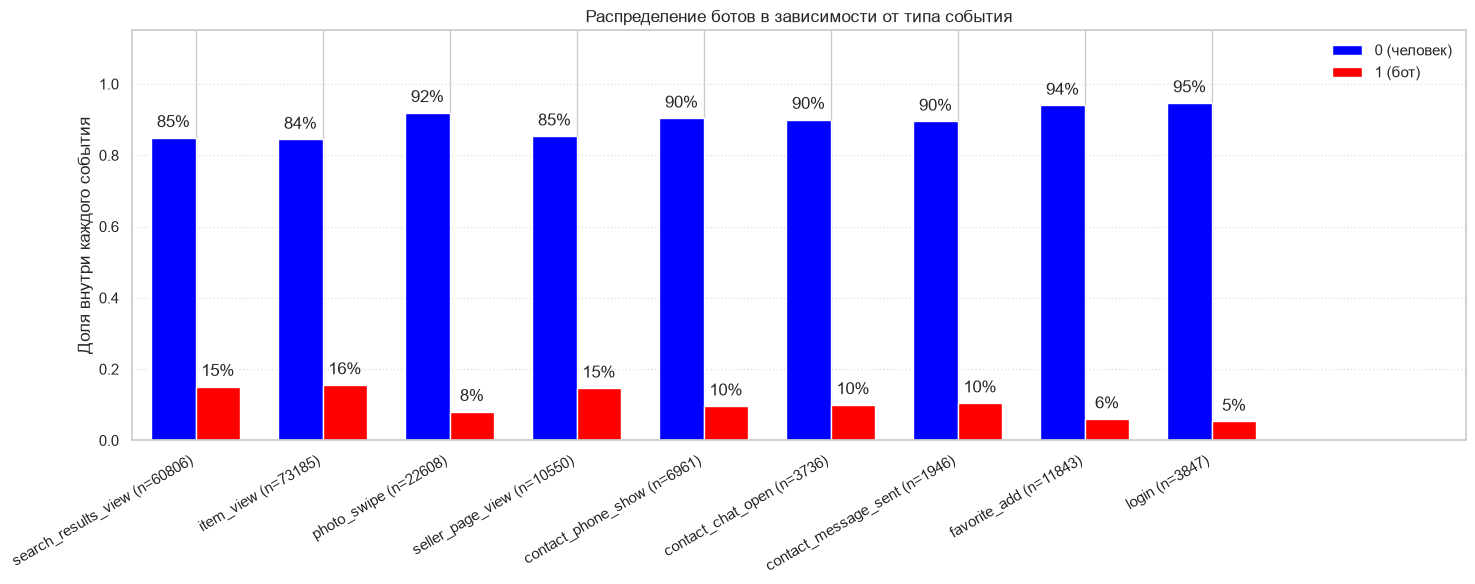

In [29]:
event_agg = X.groupby('eid')['target'].agg(count='count',bot_share='mean')
by_event_bot_stats = X.groupby('eid')['target'].value_counts(normalize=True).unstack(fill_value=0)
labels = [f'{dict_eid_to_event_name.get(eid, eid)} (n={event_agg.loc[eid, 'count']})' for eid in by_event_bot_stats.index]

fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(labels))
width = 0.35

bars_0 = ax.bar(x - width/2, by_event_bot_stats[0], width, label='0 (человек)', color='blue')
bars_1 = ax.bar(x + width/2, by_event_bot_stats[1], width, label='1 (бот)', color='red')

for bar in bars_0:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom')

for bar in bars_1:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_title(f'Распределение ботов в зависимости от типа события')
ax.set_ylabel('Доля внутри каждого события')
ax.set_xlim(-0.5, len(labels) + 1)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Посмотрим, что будет, если объединить в более общие категории

In [30]:
EVENT_CATEGORIES = {
    'SEARCH_EVENTS': [100],
    'VIEW_EVENTS': [200, 210, 220],
    'CONTACT_EVENTS': [300, 301, 303],
    'USER_ACTIONS': [400, 500],
    'CAPTCHA_EVENTS': [900]
}

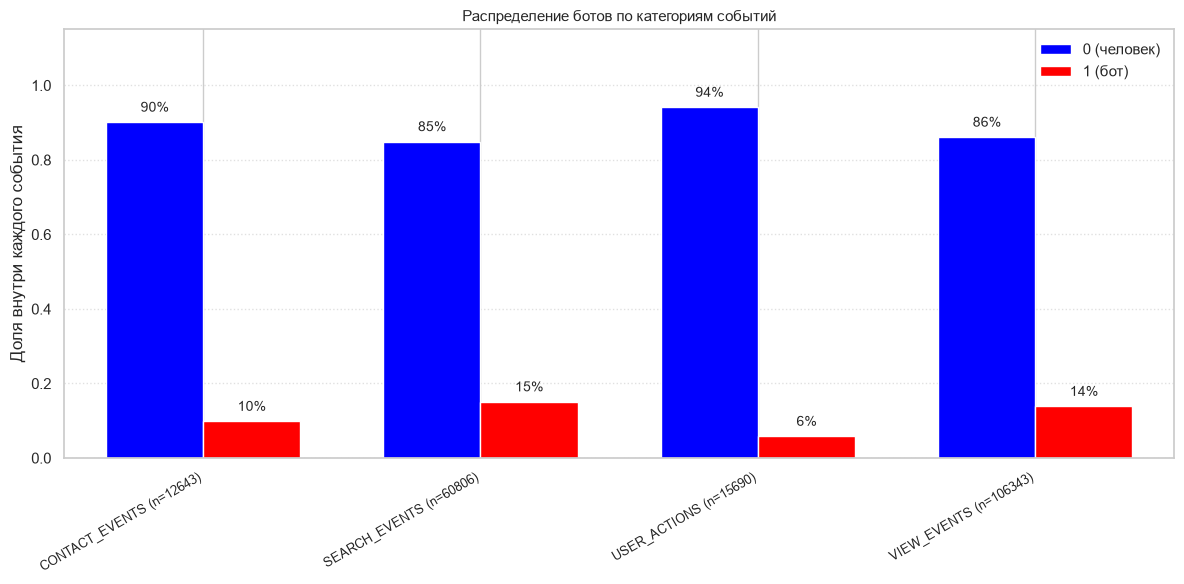

In [31]:
eid_to_category = {eid: category for category, eids in EVENT_CATEGORIES.items() for eid in eids}

X['event_category'] = X['eid'].map(eid_to_category)

category_agg = X.groupby('event_category')['target'].agg(count='count', bot_share='mean')
by_cat_bot_stats = X.groupby('event_category')['target'].value_counts(normalize=True).unstack(fill_value=0)
labels = [f'{cat} (n={category_agg.loc[cat, 'count']})' for cat in by_cat_bot_stats.index]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(labels))
width = 0.35

bars_0 = ax.bar(x - width/2, by_cat_bot_stats[0], width, label='0 (человек)', color='blue')
bars_1 = ax.bar(x + width/2, by_cat_bot_stats[1], width, label='1 (бот)', color='red')

for bar in bars_0:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom', fontsize=10)

for bar in bars_1:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Доля внутри каждого события')
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(frameon=False)
ax.set_title('Распределение ботов по категориям событий', fontsize=11)

plt.tight_layout()
plt.show()

Оставим более общие категории

In [32]:
X = X.drop('eid', axis=1)

## График распределенеи таргета в зависимости от, того сколько дубликатов было до чистки

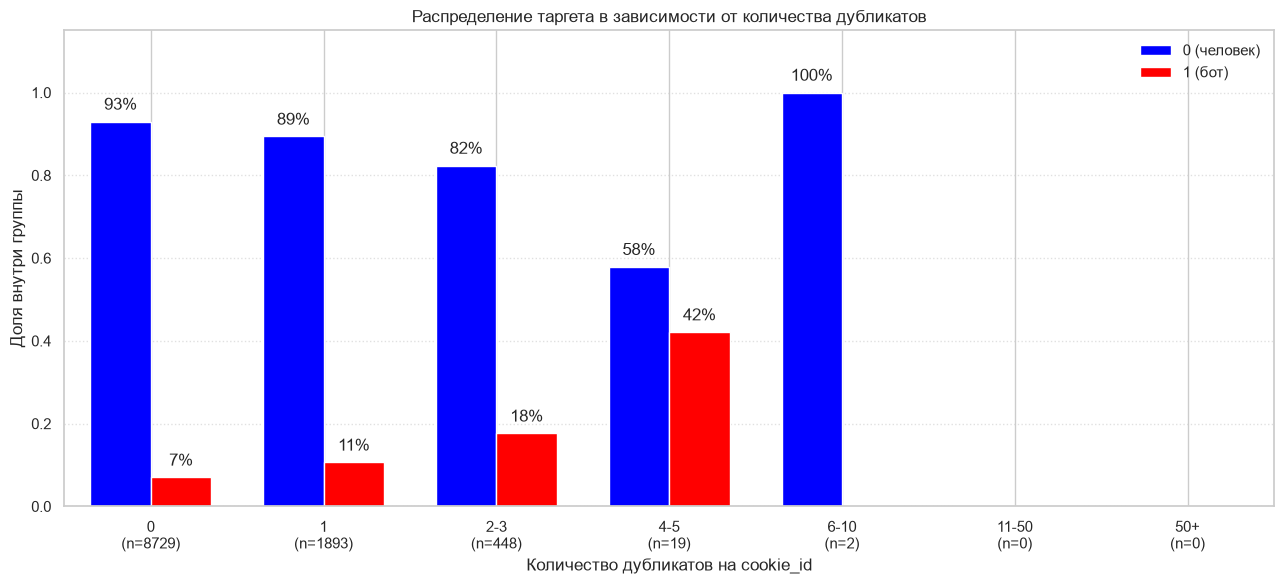

In [33]:
cookie_duplicates = X.groupby('cookie_id').agg(cnt_duplicate=('cnt_duplicate', 'max'), target=('target', 'first'))

bins = [-1, 0, 1, 3, 5, 10, 50, np.inf]
bin_labels = ['0', '1', '2-3', '4-5', '6-10', '11-50', '50+']
cookie_duplicates['dup_group'] = pd.cut(cookie_duplicates['cnt_duplicate'], bins=bins, labels=bin_labels)
group_agg = cookie_duplicates.groupby('dup_group', observed=False)['target'].agg(total_cookies='count')

by_dup_bot_stats = cookie_duplicates.groupby('dup_group', observed=False)['target'].value_counts(normalize=True).unstack(fill_value=0)

labels = [f'{group}\n(n={group_agg.loc[group, 'total_cookies']})' for group in by_dup_bot_stats.index]

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(labels))
width = 0.35

bars_0 = ax.bar(x - width/2, by_dup_bot_stats[0], width, label='0 (человек)', color='blue')
bars_1 = ax.bar(x + width/2, by_dup_bot_stats[1], width, label='1 (бот)', color='red')

for bar in bars_0:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom')

for bar in bars_1:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Распределение таргета в зависимости от количества дубликатов')
ax.set_xlabel('Количество дубликатов на cookie_id')
ax.set_ylabel('Доля внутри группы')
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## График распределение таргета в зависимости от кол-во событий в окне

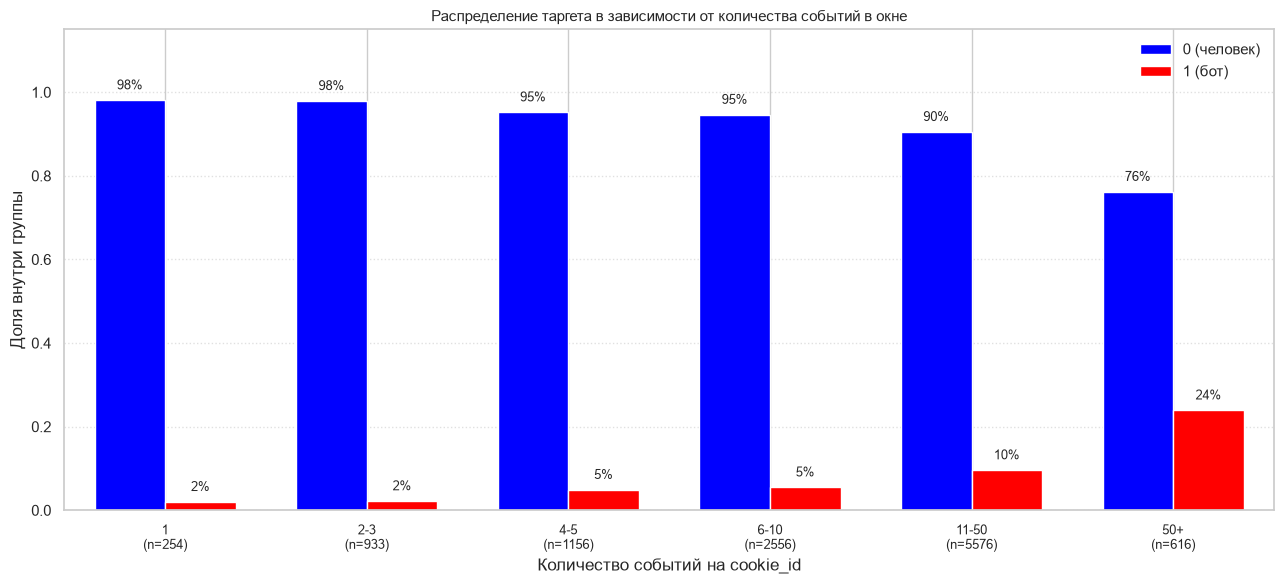

In [34]:
cookie_duplicates = X.groupby('cookie_id').agg(cnt_duplicate=('event_ts', 'count'), target=('target', 'first'))
bins = [0, 1, 3, 5, 10, 50, np.inf]
bin_labels = ['1', '2-3', '4-5', '6-10', '11-50', '50+']
cookie_duplicates['dup_group'] = pd.cut(cookie_duplicates['cnt_duplicate'], bins=bins, labels=bin_labels)
group_agg = cookie_duplicates.groupby('dup_group', observed=False)['target'].agg(total_cookies='count')

by_dup_bot_stats = cookie_duplicates.groupby('dup_group', observed=False)['target'].value_counts(normalize=True).unstack(fill_value=0)
labels = [f'{group}\n(n={group_agg.loc[group, 'total_cookies']})' for group in by_dup_bot_stats.index]

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(labels))
width = 0.35

bars_0 = ax.bar(x - width/2, by_dup_bot_stats[0], width, label='0 (человек)', color='blue')
bars_1 = ax.bar(x + width/2, by_dup_bot_stats[1], width, label='1 (бот)', color='red')

for bar in bars_0:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom', fontsize=9)

for bar in bars_1:
    yval = bar.get_height()
    if yval > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_title('Распределение таргета в зависимости от количества событий в окне', fontsize=11)
ax.set_xlabel('Количество событий на cookie_id')
ax.set_ylabel('Доля внутри группы')
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [35]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 195482 entries, 0 to 195481
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   cookie_id          195482 non-null  str           
 1   cookie_created_at  195482 non-null  datetime64[us]
 2   window_start_ts    195482 non-null  datetime64[us]
 3   event_ts           195482 non-null  datetime64[us]
 4   window_end_ts      195482 non-null  datetime64[us]
 5   platform           195482 non-null  str           
 6   user_agent         195482 non-null  str           
 7   item_id            130829 non-null  float64       
 8   item_category      180083 non-null  str           
 9   item_location      185792 non-null  str           
 10  seller_type        118966 non-null  str           
 11  search_query       60806 non-null   str           
 12  search_page        60806 non-null   float64       
 13  pointer_x          65283 non-null   float64       
 14 

## Итого:
1. item_id(надо перевести в инт, а то странно id в виде флоата) будем разбивать на две колонки is_nan_item_id - 0, если нет item_id, то в item_id - -1, а 1, если есть значение item_id, то в item_id значение остается 
2. item_category, item_location, search_query, seller_type по такой же логике, только вместо 0 - пустая строка
3. search_page(это же потом в инт надо), pointer_x, pointer_y по логике item_id


In [36]:
num_cols = ['item_id', 'search_page', 'pointer_x', 'pointer_y']
for col in num_cols:
    X[f'is_nan_{col}'] = X[col].isna().astype(int)
    
    X[col] = X[col].fillna(-1)
    
    if col == 'item_id' or col == 'search_page':
        X[col] = X[col].astype('int64')

text_cols_empty = ['item_category', 'item_location', 'search_query']
for col in text_cols_empty:
    X[f'is_nan_{col}'] = X[col].isna().astype(int)
    X[col] = X[col].fillna('')

X['is_nan_seller_type'] = X['seller_type'].notna().astype(int)
X['seller_type'] = X['seller_type'].fillna('missing')

In [37]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 195482 entries, 0 to 195481
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   cookie_id             195482 non-null  str           
 1   cookie_created_at     195482 non-null  datetime64[us]
 2   window_start_ts       195482 non-null  datetime64[us]
 3   event_ts              195482 non-null  datetime64[us]
 4   window_end_ts         195482 non-null  datetime64[us]
 5   platform              195482 non-null  str           
 6   user_agent            195482 non-null  str           
 7   item_id               195482 non-null  int64         
 8   item_category         195482 non-null  str           
 9   item_location         195482 non-null  str           
 10  seller_type           195482 non-null  str           
 11  search_query          195482 non-null  str           
 12  search_page           195482 non-null  int64         
 13  pointer_x 

In [38]:
# осмысленный порядок колоннок для удобства
ordered_columns = [ 
    'cookie_id',
    'cookie_created_at',
    'window_start_ts',
    'event_ts',
    'window_end_ts',
    'platform',
    'user_agent',
    'event_category',
    'cnt_duplicate',
    'item_id',
    'is_nan_item_id',
    'item_category',
    'is_nan_item_category',
    'item_location',
    'is_nan_item_location',
    'seller_type',
    'is_nan_seller_type',
    'search_query',
    'is_nan_search_query',
    'search_page',
    'is_nan_search_page',
    'pointer_x',
    'is_nan_pointer_x',
    'pointer_y',
    'is_nan_pointer_y',
    'target'
]

X = X[ordered_columns]

In [39]:
X.head()

,cookie_id,cookie_created_at,window_start_ts,event_ts,window_end_ts,platform,user_agent,event_category,cnt_duplicate,item_id,...,is_nan_seller_type,search_query,is_nan_search_query,search_page,is_nan_search_page,pointer_x,is_nan_pointer_x,pointer_y,is_nan_pointer_y,target
0,ck_d274382b19488771,2025-12-16 02:45:12,2026-04-13,2026-04-13 12:02:56,2026-04-14,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,3,1048743,...,1,,1,-1,1,675.0,0,276.0,0,0
1,ck_fbbed2ff14944ce9,2025-12-27 17:38:36,2026-04-08,2026-04-08 06:12:14,2026-04-09,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,SEARCH_EVENTS,2,-1,...,0,пылесос dyson,0,2,0,-1.0,1,-1.0,1,0
2,ck_56cc15c7c634cb9f,2026-04-10 06:13:58,2026-04-12,2026-04-12 17:16:05,2026-04-13,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,SEARCH_EVENTS,0,-1,...,0,костюм мужской,0,2,0,-1.0,1,-1.0,1,0
3,ck_f80d85f038cdacee,2025-08-23 19:05:01,2026-04-11,2026-04-11 16:08:12,2026-04-12,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,2,1000845,...,1,,1,-1,1,-1.0,1,-1.0,1,0
4,ck_e4f046f721d10f81,2026-04-08 17:40:46,2026-04-10,2026-04-10 16:50:05,2026-04-11,ios,Mozilla/5.0 (iPhone; CPU iPhone OS 15_2 like M...,VIEW_EVENTS,2,1055188,...,1,,1,-1,1,-1.0,1,-1.0,1,0


In [40]:
def preprocess_cookie_events(df, event_categories=None):
    if event_categories is None:
        event_categories = {
            'SEARCH_EVENTS': [100],
            'VIEW_EVENTS': [200, 210, 220],
            'CONTACT_EVENTS': [300, 301, 303],
            'USER_ACTIONS': [400, 500],
            'CAPTCHA_EVENTS': [900],
        }

    X = df.copy()

    X['platform'] = X['platform'].fillna('missing').astype(str).str.lower().str.strip()
    platform_map = {
        'iphone': 'ios',
        'ipad': 'ios',
        'ios': 'ios',
        'desktop': 'web',
        'web': 'web',
        'windows': 'web',
        'mac': 'web',
        'macos': 'web',
        'android': 'android',
        'missing': 'missing',
    }
    X['platform'] = X['platform'].map(platform_map).fillna(X['platform'])

    if 'event_name' in X.columns:
        _ = X.groupby('eid')['event_name'].first().to_dict()

    if 'cnt_duplicate' not in X.columns:
        is_duplicate = X.duplicated(keep='first')
        X['cnt_duplicate'] = is_duplicate.groupby(X['cookie_id']).transform('sum')
    X = X.drop_duplicates().reset_index(drop=True)

    eid_to_category = {
        eid: category
        for category, eids in event_categories.items()
        for eid in eids
    }
    X['event_category'] = X['eid'].map(eid_to_category).fillna('OTHER_EVENTS')

    if 'event_name' in X.columns:
        X = X.drop(columns=['event_name'])

    X = X.drop(columns=['eid'])

    num_cols = ['item_id', 'search_page', 'pointer_x', 'pointer_y']
    for col in num_cols:
        X[f'is_nan_{col}'] = X[col].isna().astype(int)
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(-1)
        if col in ['item_id', 'search_page']:
            X[col] = X[col].astype('int64')

    text_cols_empty = ['item_category', 'item_location', 'search_query']
    for col in text_cols_empty:
        X[f'is_nan_{col}'] = X[col].isna().astype(int)
        X[col] = X[col].fillna('')

    if 'seller_type' in X.columns:
        X['is_nan_seller_type'] = X['seller_type'].notna().astype(int)
        X['seller_type'] = X['seller_type'].fillna('missing')

    base_order = [
        'cookie_id', 'cookie_created_at', 'window_start_ts', 'event_ts', 'window_end_ts',
        'platform', 'user_agent', 'event_category', 'cnt_duplicate',
        'item_id', 'is_nan_item_id',
        'item_category', 'is_nan_item_category',
        'item_location', 'is_nan_item_location',
        'seller_type', 'is_nan_seller_type',
        'search_query', 'is_nan_search_query',
        'search_page', 'is_nan_search_page',
        'pointer_x', 'is_nan_pointer_x',
        'pointer_y', 'is_nan_pointer_y',
    ]
    if 'target' in X.columns:
        base_order.append('target')

    final_cols = [c for c in base_order if c in X.columns]
    return X[final_cols]

In [41]:
ev_tr = preprocess_cookie_events(events_in_window(events, train))
ev_te = preprocess_cookie_events(events_in_window(events, test))

# Baseline

Baseline будет константная модель

In [42]:
constant_pred = train["target"].mean()
print(f"Константное предсказание (вероятность): {constant_pred:.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

Xtr, ytr = train.drop("target", axis=1), train["target"]
for train_idx, val_idx in cv.split(Xtr, ytr):
    y_val = ytr[val_idx]
    preds = np.full_like(y_val, fill_value=constant_pred, dtype=float)
    score = precision_at_recall(y_val, preds)
    cv_scores.append(score)

print(f"Baseline Precision @ Recall >= 0.70: {np.mean(cv_scores):.4f}")

Константное предсказание (вероятность): 0.0811
Baseline Precision @ Recall >= 0.70: 0.0811


# Feature engineering

## Базовые статистики

1. delta_from_creature_to_startts — время от момента создания cookie до начала окна наблюдения (в секундах).
2. platform — самая частая платформа пользователя за сессию (мода).
3. freq — количество событий, совершенных на самой частой платформе.
4. user_agent — самый частый User-Agent строки браузера/устройства (мода).
5. event_top — самая частая категория/тип события за сессию (мода).
6. freq_top_event — количество повторений самого частого события.
7. cnt_event — общее количество событий у пользователя в окне.
8. cnt_unique_event — количество уникальных типов событий за сессию.
9. cnt_dup — среднее количество дубликатов событий.
10. item_count — количество событий, связанных с конкретными товарами (item_id != -1).
11. item_unique_count — количество уникальных просмотренных товаров.
12. item_missing_share — доля событий без указания товара (item_id == -1).
13. item_repeat_count — количество повторных просмотров/кликов по товарам (item_count - item_unique_count).
14. item_category_count — количество событий с заполненной категорией товара (item_category != '').
15. item_category_unique_count — количество уникальных категорий товаров.
16. item_category_missing_share — доля событий с пустой категорией.
17. item_category_top — самая частая категория товара (мода).
18. item_category_top_count — количество событий в самой частой категории.
19. item_category_top_share — доля самой частой категории от общего числа событий с известными категориями.
20. search_page_count — количество событий на страницах поиска (search_page != -1).
21. search_page_unique_count — количество уникальных просмотренных страниц поиска.
22. search_page_missing_share — доля событий вне поисковой выдачи (search_page == -1).
23. search_page_max — максимальный номер просмотренной страницы поиска (глубина пролистывания выдачи).
24. search_page_mean — средний номер страницы поиска.
25. search_page_std — стандартное отклонение номеров просмотренных страниц поиска.
26. pointer_count — количество событий с записанными координатами мыши (pointer_x != -1 и pointer_y != -1).
27. pointer_missing_share — доля событий без координат мыши.
28. pointer_x_mean — среднее положение курсора по оси X.
29. pointer_y_mean — среднее положение курсора по оси Y.
30. pointer_x_std — стандартное отклонение координат по оси X.
31. pointer_y_std — стандартное отклонение координат по оси Y.
32. pointer_x_range — размах движения курсора по оси X (max - min).
33. pointer_y_range — размах движения курсора по оси Y (max - min).
34. pointer_path_length — суммарная длина пройденного пути курсора (сумма Евклидовых расстояний между шагами).
35. pointer_mean_step — среднее расстояние перемещения мыши за один шаг.
36. pointer_max_step — максимальный одиночный скачок курсора за сессию.
37. search_query_text — объединенный в одну строку текст всех поисковых запросов пользователя за сессию.

In [43]:
def basic_feature(ev, meta):
    X = ev.copy()

    time_cols = [
        'cookie_created_at',
        'window_start_ts',
        'event_ts',
        'window_end_ts',
    ]
    for col in time_cols:
        X[col] = X[col].astype('int64') // 1_000_000_000

    X['delta_from_creature_to_startts'] = X['window_start_ts'] - X['cookie_created_at']
    tmp_feature_with_platform = X.groupby('cookie_id')['platform'].describe()
    tmp_feature_with_user_agent = X.groupby('cookie_id')['user_agent'].describe()
    tmp_feature_with_event = X.groupby('cookie_id')['event_category'].describe()
    tmp_feature_with_cnt_dup = X.groupby('cookie_id')['cnt_duplicate'].describe()

    valid_item_id = X['item_id'].ne(-1)
    item_id_by_cookie = X['item_id'].where(valid_item_id)
    item_count = valid_item_id.groupby(X['cookie_id']).sum()
    item_unique_count = item_id_by_cookie.groupby(X['cookie_id']).nunique()
    item_missing_share = (~valid_item_id).groupby(X['cookie_id']).mean()

    valid_item_category = X['item_category'].ne('')
    item_category_by_cookie = X['item_category'].where(valid_item_category)
    item_category_count = valid_item_category.groupby(X['cookie_id']).sum()
    item_category_unique_count = item_category_by_cookie.groupby(X['cookie_id']).nunique()
    item_category_missing_share = (~valid_item_category).groupby(X['cookie_id']).mean()
    item_category_stats = item_category_by_cookie.groupby(X['cookie_id']).agg(item_category_top=lambda values: values.mode().iloc[0] if not values.mode().empty else '',
                                                                            item_category_top_count=lambda values: values.value_counts().iloc[0] if not values.value_counts().empty else 0)
    item_category_top_share = item_category_stats['item_category_top_count'] / item_category_count.replace(0, np.nan).fillna(0)

    valid_search_page = X['search_page'].ne(-1)
    search_page_by_cookie = X['search_page'].where(valid_search_page)
    search_page_count = valid_search_page.groupby(X['cookie_id']).sum()
    search_page_unique_count = search_page_by_cookie.groupby(X['cookie_id']).nunique()
    search_page_missing_share = (~valid_search_page).groupby(X['cookie_id']).mean()
    search_page_max = search_page_by_cookie.groupby(X['cookie_id']).max()
    search_page_mean = search_page_by_cookie.groupby(X['cookie_id']).mean()
    search_page_std = search_page_by_cookie.groupby(X['cookie_id']).std().fillna(0)

    valid_pointer = X['pointer_x'].ne(-1) & X['pointer_y'].ne(-1)
    pointer_x_by_cookie = X['pointer_x'].where(valid_pointer)
    pointer_y_by_cookie = X['pointer_y'].where(valid_pointer)
    pointer_count = valid_pointer.groupby(X['cookie_id']).sum()
    pointer_missing_share = (~valid_pointer).groupby(X['cookie_id']).mean()
    pointer_x_mean = pointer_x_by_cookie.groupby(X['cookie_id']).mean()
    pointer_y_mean = pointer_y_by_cookie.groupby(X['cookie_id']).mean()
    pointer_x_std = pointer_x_by_cookie.groupby(X['cookie_id']).std().fillna(0)
    pointer_y_std = pointer_y_by_cookie.groupby(X['cookie_id']).std().fillna(0)
    pointer_x_range = pointer_x_by_cookie.groupby(X['cookie_id']).agg(lambda values: values.max() - values.min())
    pointer_y_range = pointer_y_by_cookie.groupby(X['cookie_id']).agg(lambda values: values.max() - values.min())

    pointer_events = (
        X.loc[valid_pointer, ['cookie_id', 'event_ts', 'pointer_x', 'pointer_y']]
        .sort_values(['cookie_id', 'event_ts'])
    )
    pointer_dx = pointer_events.groupby('cookie_id')['pointer_x'].diff()
    pointer_dy = pointer_events.groupby('cookie_id')['pointer_y'].diff()
    pointer_step = np.sqrt(pointer_dx.pow(2) + pointer_dy.pow(2))
    pointer_path_length = pointer_step.groupby(pointer_events['cookie_id']).sum()
    pointer_mean_step = pointer_step.groupby(pointer_events['cookie_id']).mean().fillna(0)
    pointer_max_step = pointer_step.groupby(pointer_events['cookie_id']).max().fillna(0)

    search_query_text = X['search_query'].fillna('').astype(str).groupby(X['cookie_id']).agg(lambda values: ' '.join(value for value in values if value))

    feature_dict = {
        'delta_from_creature_to_startts': X.groupby('cookie_id')['delta_from_creature_to_startts'].min(),
        'platform': tmp_feature_with_platform['top'].values,
        'freq': tmp_feature_with_platform['freq'].values,
        'user_agent': tmp_feature_with_user_agent['top'].values,
        'event_top': tmp_feature_with_event['top'].values,
        'freq_top_event': tmp_feature_with_event['freq'].values,
        'cnt_event': tmp_feature_with_event['count'].values,
        'cnt_unique_event': tmp_feature_with_event['unique'].values,
        'cnt_dup': tmp_feature_with_cnt_dup['mean'].values,
        'item_count': item_count,
        'item_unique_count': item_unique_count,
        'item_missing_share': item_missing_share,
        'item_repeat_count': item_count - item_unique_count,
        'item_category_count': item_category_count,
        'item_category_unique_count': item_category_unique_count,
        'item_category_missing_share': item_category_missing_share,
        'item_category_top': item_category_stats['item_category_top'],
        'item_category_top_count': item_category_stats['item_category_top_count'],
        'item_category_top_share': item_category_top_share,
        'search_page_count': search_page_count,
        'search_page_unique_count': search_page_unique_count,
        'search_page_missing_share': search_page_missing_share,
        'search_page_max': search_page_max,
        'search_page_mean': search_page_mean,
        'search_page_std': search_page_std,
        'pointer_count': pointer_count,
        'pointer_missing_share': pointer_missing_share,
        'pointer_x_mean': pointer_x_mean,
        'pointer_y_mean': pointer_y_mean,
        'pointer_x_std': pointer_x_std,
        'pointer_y_std': pointer_y_std,
        'pointer_x_range': pointer_x_range,
        'pointer_y_range': pointer_y_range,
        'pointer_path_length': pointer_path_length,
        'pointer_mean_step': pointer_mean_step,
        'pointer_max_step': pointer_max_step,
        'search_query_text': search_query_text,
    }

    f = pd.DataFrame(feature_dict).reset_index()
    f = meta[['cookie_id']].merge(f, on='cookie_id', how='left')
    f['search_query_text'] = f['search_query_text'].fillna('')
    return f.fillna(0)

Xtr = basic_feature(ev_tr, train)
Xte = basic_feature(ev_te, test)
ytr = train.target.values
Xtr.head()

,cookie_id,delta_from_creature_to_startts,platform,freq,user_agent,event_top,freq_top_event,cnt_event,cnt_unique_event,cnt_dup,...,pointer_x_mean,pointer_y_mean,pointer_x_std,pointer_y_std,pointer_x_range,pointer_y_range,pointer_path_length,pointer_mean_step,pointer_max_step,search_query_text
0,ck_54a059eb7d3ea68b,11716,android,7,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,VIEW_EVENTS,4,7,2,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,новостройка квартира с ремонтом купить 1к квар...
1,ck_7e4de46eeab82974,16811,web,41,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,30,41,4,0.0,...,917.868421,567.605263,509.231969,272.953569,1905.0,949.0,28147.128076,760.733191,1762.325736,снять 1к квартиру снять квартиру у метро аренд...
2,ck_9320229ef6304522,2851,web,36,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,13,36,4,0.0,...,936.457143,556.657143,602.124295,312.027426,1869.0,1035.0,31705.744761,932.521905,1790.046089,стартер конструктор lego бампер передний манеж...
3,ck_30ccd25bc1714ed9,47,web,21,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,16,21,3,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,велосипед детский самокат детский коляска 2в1
4,ck_a77c5f05948cdeef,8194,web,28,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,VIEW_EVENTS,19,28,4,1.0,...,978.000000,639.740741,450.561957,295.966031,1761.0,1036.0,19984.106577,768.619484,1619.980864,ноутбук игровой корм для собак переноска кварт...


## Сессионные и категориальные признаки

Следующие признаки были добавлены на основе следующих графиков из раздела Чиста и EDA: Распределение таргета в зависимости от количества событий в окне, Распределение таргета в зависимости от количества дубликатов, Топ-50 User-Agent с наибольшей долей ботов, Распределение таргета по платформам

1. event_share_category — доля каждого конкретного типа события (event_category) от общего количества событий пользователя за сессию.
2. platform_share_platform — доля каждой используемой платформы (platform) от общего количества событий пользователя за сессию.
3. events_in_window — общее число событий у пользователя в окне наблюдения (размер сессии).
4. unique_event_categories — количество уникальных категорий/типов событий за сессию.
5. duplicate_events — максимальное количество зафиксированных дубликатов событий у пользователя.
6. duplicate_share — доля сдублированных событий от общего объема действий (duplicate_events / events_in_window).
7. unique_platforms — количество уникальных платформ, зафиксированных у одного cookie_id (показывает мультиплатформенность или смену User-Agent).
8. unique_user_agents — количество уникальных строк User-Agent, зафиксированных у пользователя за сессию.
9. user_agent_length — длина первого строки User-Agent пользователя в символах.
10. user_agent_frequency_mean — средняя глобальная популярность (частота встречаемости) User-Agent пользователя во всем датасете.
11. user_agent_frequency_min — минимальная глобальная популярность User-Agent пользователя во всем датасете (выявляет редкие или сгенерированные строки).

In [44]:
def advanced_features(ev, meta):
    X = ev.copy()

    features = pd.DataFrame(index=meta['cookie_id'])
    features.index.name = 'cookie_id'

    event_counts = pd.crosstab(X['cookie_id'], X['event_category'])
    event_shares = event_counts.div(event_counts.sum(axis=1), axis=0)
    event_shares.columns = [f'event_share_{column}' for column in event_shares.columns]

    platform_counts = pd.crosstab(X['cookie_id'], X['platform'])
    platform_shares = platform_counts.div(platform_counts.sum(axis=1), axis=0)
    platform_shares.columns = [f'platform_share_{column}' for column in platform_shares.columns]

    user_agent_frequency = X['user_agent'].value_counts(dropna=False)
    X['user_agent_frequency'] = X['user_agent'].map(user_agent_frequency)
    grouped = X.groupby('cookie_id')

    features['events_in_window'] = grouped.size()
    features['unique_event_categories'] = grouped['event_category'].nunique()
    features['duplicate_events'] = grouped['cnt_duplicate'].max()
    features['duplicate_share'] = features['duplicate_events'] / features['events_in_window']
    features['unique_platforms'] = grouped['platform'].nunique()
    features['unique_user_agents'] = grouped['user_agent'].nunique()
    features['user_agent_length'] = grouped['user_agent'].first().fillna('').astype(str).str.len()
    features['user_agent_frequency_mean'] = grouped['user_agent_frequency'].mean()
    features['user_agent_frequency_min'] = grouped['user_agent_frequency'].min()

    features = features.join(event_shares, how='left')
    features = features.join(platform_shares, how='left')
    return features.reset_index().fillna(0)


advanced_train = advanced_features(ev_tr, train)
advanced_test = advanced_features(ev_te, test)

print(f'Дополнительных признаков: {advanced_train.shape[1] - 1}')
advanced_train.head()

Дополнительных признаков: 16


,cookie_id,events_in_window,unique_event_categories,duplicate_events,duplicate_share,unique_platforms,unique_user_agents,user_agent_length,user_agent_frequency_mean,user_agent_frequency_min,event_share_CONTACT_EVENTS,event_share_SEARCH_EVENTS,event_share_USER_ACTIONS,event_share_VIEW_EVENTS,platform_share_android,platform_share_ios,platform_share_web
0,ck_54a059eb7d3ea68b,7,2,0,0.000000,1,1,48,937.0,937,0.000000,0.428571,0.000000,0.571429,1.0,0.0,0.0
1,ck_7e4de46eeab82974,41,4,0,0.000000,1,1,130,2130.0,2130,0.024390,0.195122,0.048780,0.731707,0.0,0.0,1.0
2,ck_9320229ef6304522,36,4,0,0.000000,1,1,111,1981.0,1981,0.111111,0.361111,0.166667,0.361111,0.0,0.0,1.0
3,ck_30ccd25bc1714ed9,21,3,0,0.000000,1,1,111,1820.0,1820,0.095238,0.142857,0.000000,0.761905,0.0,0.0,1.0
4,ck_a77c5f05948cdeef,28,4,1,0.035714,1,1,117,1825.0,1825,0.035714,0.214286,0.071429,0.678571,0.0,0.0,1.0


In [45]:
Xtr = Xtr.merge(advanced_train, on='cookie_id', how='left')
Xte = Xte.merge(advanced_test, on='cookie_id', how='left')

Xtr = Xtr.fillna(0)
Xte = Xte.fillna(0)

print(f'Признаков после объединения: {Xtr.shape[1] - 1}')
Xtr.head()

Признаков после объединения: 53


,cookie_id,delta_from_creature_to_startts,platform,freq,user_agent,event_top,freq_top_event,cnt_event,cnt_unique_event,cnt_dup,...,user_agent_length,user_agent_frequency_mean,user_agent_frequency_min,event_share_CONTACT_EVENTS,event_share_SEARCH_EVENTS,event_share_USER_ACTIONS,event_share_VIEW_EVENTS,platform_share_android,platform_share_ios,platform_share_web
0,ck_54a059eb7d3ea68b,11716,android,7,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,VIEW_EVENTS,4,7,2,0.0,...,48,937.0,937,0.000000,0.428571,0.000000,0.571429,1.0,0.0,0.0
1,ck_7e4de46eeab82974,16811,web,41,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,30,41,4,0.0,...,130,2130.0,2130,0.024390,0.195122,0.048780,0.731707,0.0,0.0,1.0
2,ck_9320229ef6304522,2851,web,36,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,13,36,4,0.0,...,111,1981.0,1981,0.111111,0.361111,0.166667,0.361111,0.0,0.0,1.0
3,ck_30ccd25bc1714ed9,47,web,21,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,16,21,3,0.0,...,111,1820.0,1820,0.095238,0.142857,0.000000,0.761905,0.0,0.0,1.0
4,ck_a77c5f05948cdeef,8194,web,28,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,VIEW_EVENTS,19,28,4,1.0,...,117,1825.0,1825,0.035714,0.214286,0.071429,0.678571,0.0,0.0,1.0


## Признаки основанные на разнинце между событиями

Добавим разницу между событиями и разные статистики про это: средние, дисперсию, стандартное и тд

1. event_gap_count — количество зафиксированных временных паузах (интервалов) между последовательными событиями у пользователя.
2. event_gap_mean — средняя продолжительность паузы между событиями в секундах.
3. event_gap_median — медианная продолжительность паузы между событиями в секундах.
4. event_gap_std — стандартное отклонение длительности пауз (показывает неравномерность темпа кликов).
5. event_gap_min — минимальная зафиксированная пауза между двумя событиями подряд в секундах.
6. event_gap_max — максимальная зафиксированная пауза между событиями за сессию в секундах.
7. event_gap_q25 — 25-й перцентиль (первый квартиль) длительности временных пауз.
8. event_gap_q75 — 75-й перцентиль (третий квартиль) длительности временных пауз.
9. event_gap_short_share — доля быстрых переходов между событиями ($\le 1$ секунды).
10. event_gap_long_share — доля длинных пауз между событиями ($\ge 60$ секунд).

In [46]:
def inter_event_features(ev, meta):
    ordered_events = ev.sort_values(['cookie_id', 'event_ts']).copy()
    ordered_events['event_gap_seconds'] = ordered_events.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()

    gaps = ordered_events.dropna(subset=['event_gap_seconds'])
    grouped_gaps = gaps.groupby('cookie_id')['event_gap_seconds']

    features = pd.DataFrame(index=meta['cookie_id'])
    features.index.name = 'cookie_id'
    features['event_gap_count'] = grouped_gaps.count()
    features['event_gap_mean'] = grouped_gaps.mean()
    features['event_gap_median'] = grouped_gaps.median()
    features['event_gap_std'] = grouped_gaps.std()
    features['event_gap_min'] = grouped_gaps.min()
    features['event_gap_max'] = grouped_gaps.max()
    features['event_gap_q25'] = grouped_gaps.quantile(0.25)
    features['event_gap_q75'] = grouped_gaps.quantile(0.75)
    features['event_gap_short_share'] = grouped_gaps.apply(lambda values: (values <= 1).mean())
    features['event_gap_long_share'] = grouped_gaps.apply(lambda values: (values >= 60).mean())

    return features.reset_index().fillna(0)


inter_event_train = inter_event_features(ev_tr, train)
inter_event_test = inter_event_features(ev_te, test)

Xtr = Xtr.merge(inter_event_train, on='cookie_id', how='left').fillna(0)
Xte = Xte.merge(inter_event_test, on='cookie_id', how='left').fillna(0)

print(f'Признаков после добавления интервалов: {Xtr.shape[1] - 1}')
Xtr.head()

Признаков после добавления интервалов: 63


,cookie_id,delta_from_creature_to_startts,platform,freq,user_agent,event_top,freq_top_event,cnt_event,cnt_unique_event,cnt_dup,...,event_gap_count,event_gap_mean,event_gap_median,event_gap_std,event_gap_min,event_gap_max,event_gap_q25,event_gap_q75,event_gap_short_share,event_gap_long_share
0,ck_54a059eb7d3ea68b,11716,android,7,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,VIEW_EVENTS,4,7,2,0.0,...,6.0,27.833333,21.0,29.949402,1.0,84.0,9.50,31.00,0.166667,0.166667
1,ck_7e4de46eeab82974,16811,web,41,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,30,41,4,0.0,...,40.0,986.900000,57.5,2416.286861,2.0,8511.0,19.00,82.25,0.000000,0.475000
2,ck_9320229ef6304522,2851,web,36,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,13,36,4,0.0,...,35.0,1042.600000,22.0,2306.449400,1.0,8350.0,14.50,73.00,0.028571,0.285714
3,ck_30ccd25bc1714ed9,47,web,21,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,16,21,3,0.0,...,20.0,861.050000,54.5,2502.081501,6.0,8604.0,37.25,70.00,0.000000,0.450000
4,ck_a77c5f05948cdeef,8194,web,28,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,VIEW_EVENTS,19,28,4,1.0,...,27.0,707.333333,52.0,1748.439172,22.0,7224.0,32.50,106.50,0.000000,0.481481


## Геометрические и динамические признаки курсора

1. pointer_has_no_coords — бинарный флаг полных ботов/скриптов, у которых за всю сессию не зафиксировано ни одного события с координатами.
2. pointer_bbox_area — площадь прямоугольника охвата курсора (width * height), показывающая физическую область экрана, в которой действовал пользователь.
3. pointer_aspect_ratio — соотношение максимальной X к максимальной Y координате (x_max / y_max), помогающее вычислять несоответствие заявленной платформы и реальной ориентации экрана (spoofing).
4. pointer_unique_share — доля уникальных координатных точек от общего числа событий с курсором (у ботов часто клики идут пиксель-в-пиксель по фиксированным координатам).
5. pointer_zero_coord_share — доля событий с координатами строго (0, 0).
6. pointer_dist_median — медианная дистанция перемещения курсора между последовательными событиями в пикселях.
7. pointer_speed_mean — средняя скорость перемещения курсора за сессию (пикселей в секунду).
8. pointer_speed_median — медианная скорость перемещения курсора за сессию.
9. pointer_speed_max — максимальная зафиксированная скорость перемещения курсора за сессию.
10. pointer_fast_move_share — доля аномально быстрых перемещений мыши (speed > 3000 px/sec), характерных для "телепортации" курсора эмуляторами.
11. pointer_ortho_move_share — доля строго ортогональных перемещений курсора (движения строго по горизонтали или строго по вертикали).

In [47]:
def pointer_features(ev, meta):
    features = pd.DataFrame(index=meta["cookie_id"])
    features.index.name = "cookie_id"

    ev_all = ev.copy()
    ev_all["is_nan_coord"] = ev_all["pointer_x"].isna().astype(int)

    grouped_all = ev_all.groupby("cookie_id")
    total_events = grouped_all.size()
    nan_count = grouped_all["is_nan_coord"].sum()

    features["pointer_has_no_coords"] = (nan_count == total_events).astype(int)

    valid_events = ev.dropna(subset=["pointer_x", "pointer_y"]).copy()
    valid_events = valid_events.sort_values(["cookie_id", "event_ts"])

    if valid_events.empty:
        return features.reset_index().fillna(0)

    grouped_valid = valid_events.groupby("cookie_id")
    valid_count = grouped_valid.size()

    x_min = grouped_valid["pointer_x"].min()
    x_max = grouped_valid["pointer_x"].max()
    y_min = grouped_valid["pointer_y"].min()
    y_max = grouped_valid["pointer_y"].max()

    bbox_w = x_max - x_min
    bbox_h = y_max - y_min

    features["pointer_bbox_area"] = bbox_w * bbox_h
    features["pointer_aspect_ratio"] = x_max / (y_max + 1e-5)

    valid_events["coord_tuple"] = list(zip(valid_events["pointer_x"], valid_events["pointer_y"]))
    unique_coords = valid_events.groupby("cookie_id")["coord_tuple"].nunique()
    features["pointer_unique_share"] = unique_coords / valid_count

    valid_events["is_zero_coord"] = ((valid_events["pointer_x"] == 0) & (valid_events["pointer_y"] == 0)).astype(int)
    zero_coords = valid_events.groupby("cookie_id")["is_zero_coord"].sum()
    features["pointer_zero_coord_share"] = zero_coords / valid_count

    valid_events["delta_x"] = valid_events.groupby("cookie_id")["pointer_x"].diff()
    valid_events["delta_y"] = valid_events.groupby("cookie_id")["pointer_y"].diff()
    valid_events["delta_t"] = valid_events.groupby("cookie_id")["event_ts"].diff().dt.total_seconds()

    valid_events["distance"] = np.sqrt(valid_events["delta_x"] ** 2 + valid_events["delta_y"] ** 2)
    valid_events["speed"] = valid_events["distance"] / np.maximum(valid_events["delta_t"], 0.001)

    valid_events["is_orthogonal"] = ((valid_events["delta_x"] == 0) | (valid_events["delta_y"] == 0)) & (valid_events["distance"] > 0)
    valid_events["is_fast_move"] = valid_events["speed"] > 3000

    moves = valid_events.dropna(subset=["distance"])
    grouped_moves = moves.groupby("cookie_id")

    features["pointer_dist_median"] = grouped_moves["distance"].median()
    features["pointer_speed_mean"] = grouped_moves["speed"].mean()
    features["pointer_speed_median"] = grouped_moves["speed"].median()
    features["pointer_speed_max"] = grouped_moves["speed"].max()
    features["pointer_fast_move_share"] = grouped_moves["is_fast_move"].mean()
    features["pointer_ortho_move_share"] = grouped_moves["is_orthogonal"].mean()

    return features.reset_index().fillna(0)

pointer_train = pointer_features(ev_tr, train)
pointer_test = pointer_features(ev_te, test)

Xtr = Xtr.merge(pointer_train, on="cookie_id", how="left").fillna(0)
Xte = Xte.merge(pointer_test, on="cookie_id", how="left").fillna(0)

print(f"Признаков после добавления новых признаков: {Xtr.shape[1] - 1}")
Xtr.head()

Признаков после добавления новых признаков: 74


,cookie_id,delta_from_creature_to_startts,platform,freq,user_agent,event_top,freq_top_event,cnt_event,cnt_unique_event,cnt_dup,...,pointer_bbox_area,pointer_aspect_ratio,pointer_unique_share,pointer_zero_coord_share,pointer_dist_median,pointer_speed_mean,pointer_speed_median,pointer_speed_max,pointer_fast_move_share,pointer_ortho_move_share
0,ck_54a059eb7d3ea68b,11716,android,7,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,VIEW_EVENTS,4,7,2,0.0,...,0.0,1.000010,0.142857,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,ck_7e4de46eeab82974,16811,web,41,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,30,41,4,0.0,...,2011032.0,1.811016,0.951220,0.0,735.974040,37.751250,13.936687,277.824765,0.0,0.0
2,ck_9320229ef6304522,2851,web,36,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,13,36,4,0.0,...,2015490.0,1.801324,1.000000,0.0,867.844456,91.596307,31.718806,1341.931816,0.0,0.0
3,ck_30ccd25bc1714ed9,47,web,21,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,16,21,3,0.0,...,0.0,1.000010,0.047619,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,ck_a77c5f05948cdeef,8194,web,28,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,VIEW_EVENTS,19,28,4,1.0,...,1867264.0,1.720461,1.000000,0.0,597.850316,11.966917,9.313703,39.971231,0.0,0.0


## Дополнительные сессионные и поведенческие признаки

1. cnt_event — общее количество событий у пользователя за сессию.
2. cnt_unique_event — количество уникальных типов событий (event_top) за сессию.
3. event_diversity — разнообразие действий пользователя (cnt_unique_event / cnt_event).
4. freq_top_event — количество повторений самого популярного события у пользователя.
5. top_event_ratio — доля самого популярного события от общего числа действий за сессию (freq_top_event / cnt_event).
6. search_count — общее количество событий с использованием строки поиска за сессию.
7. search_share — доля поисковых событий от общего количества действий за сессию (search_count / cnt_event).
8. query_len_max — максимальная длина поискового запроса в символах.
9. query_len_mean — средняя длина поискового запроса в символах.
10. query_words_max — максимальное количество слов в поисковом запросе.
11. cnt_unique_categories — количество уникальных категорий товаров (item_category_top), с которыми взаимодействовал пользователь.
12. is_mobile_user — бинарный флаг использования мобильного устройства за сессию (по ключевым словам в user_agent).
13. log_cnt_event — сжатый логарифм общего количества событий (log1p(cnt_event)), сглаживающий длинные хвосты тяжелых пользователей.

In [48]:
def session_event_features(ev, meta):
    features = pd.DataFrame(index=meta["cookie_id"])
    features.index.name = "cookie_id"

    ev_df = ev.copy()

    grouped = ev_df.groupby("cookie_id")

    cnt_event = grouped.size()
    cnt_unique_event = grouped["event_top"].nunique() if "event_top" in ev_df.columns else grouped.size()

    features["cnt_event"] = cnt_event
    features["cnt_unique_event"] = cnt_unique_event
    features["event_diversity"] = cnt_unique_event / cnt_event

    if "event_top" in ev_df.columns:
        event_counts = ev_df.groupby(["cookie_id", "event_top"]).size().unstack(fill_value=0)
        freq_top_event = event_counts.max(axis=1)
        features["freq_top_event"] = freq_top_event
        features["top_event_ratio"] = freq_top_event / cnt_event

    if "search_query_text" in ev_df.columns:
        ev_df["has_search"] = ev_df["search_query_text"].notna().astype(int)
        ev_df["query_len"] = ev_df["search_query_text"].fillna("").astype(str).str.len()
        ev_df["query_words"] = ev_df["search_query_text"].fillna("").astype(str).str.split().str.len()

        grouped_search = ev_df.groupby("cookie_id")

        search_count = grouped_search["has_search"].sum()
        features["search_count"] = search_count
        features["search_share"] = search_count / cnt_event
        features["query_len_max"] = grouped_search["query_len"].max()
        features["query_len_mean"] = grouped_search["query_len"].mean()
        features["query_words_max"] = grouped_search["query_words"].max()

    if "item_category_top" in ev_df.columns:
        features["cnt_unique_categories"] = grouped["item_category_top"].nunique()

    if "user_agent" in ev_df.columns:
        ua_lower = ev_df["user_agent"].fillna("").astype(str).str.lower()
        ev_df["is_mobile"] = ua_lower.str.contains("android|iphone").astype(int)
        features["is_mobile_user"] = grouped["is_mobile"].max()

    features["log_cnt_event"] = np.log1p(cnt_event)

    return features.reset_index().fillna(0)


session_train = session_event_features(ev_tr, train)
session_test = session_event_features(ev_te, test)

Xtr = Xtr.merge(session_train, on="cookie_id", how="left").fillna(0)
Xte = Xte.merge(session_test, on="cookie_id", how="left").fillna(0)

print(f"Признаков после добавления сессионных фичей: {Xtr.shape[1] - 1}")
Xtr.head()

Признаков после добавления сессионных фичей: 79


,cookie_id,delta_from_creature_to_startts,platform,freq,user_agent,event_top,freq_top_event,cnt_event_x,cnt_unique_event_x,cnt_dup,...,pointer_speed_mean,pointer_speed_median,pointer_speed_max,pointer_fast_move_share,pointer_ortho_move_share,cnt_event_y,cnt_unique_event_y,event_diversity,is_mobile_user,log_cnt_event
0,ck_54a059eb7d3ea68b,11716,android,7,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,VIEW_EVENTS,4,7,2,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,7,7,1.0,1,2.079442
1,ck_7e4de46eeab82974,16811,web,41,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,30,41,4,0.0,...,37.751250,13.936687,277.824765,0.0,0.0,41,41,1.0,0,3.737670
2,ck_9320229ef6304522,2851,web,36,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,13,36,4,0.0,...,91.596307,31.718806,1341.931816,0.0,0.0,36,36,1.0,0,3.610918
3,ck_30ccd25bc1714ed9,47,web,21,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,VIEW_EVENTS,16,21,3,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,21,21,1.0,0,3.091042
4,ck_a77c5f05948cdeef,8194,web,28,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,VIEW_EVENTS,19,28,4,1.0,...,11.966917,9.313703,39.971231,0.0,0.0,28,28,1.0,0,3.367296


# Решение

In [ ]:
cat_features = [
    'platform',
    'user_agent',
    'event_top',
    'item_category_top',
]
text_features = ['search_query_text']

feature_columns = Xtr.columns.drop('cookie_id').tolist()
X_model = Xtr[feature_columns].copy()
X_test = Xte[feature_columns].copy()

for column in cat_features + text_features:
    X_model[column] = X_model[column].fillna('').astype(str)
    X_test[column] = X_test[column].fillna('').astype(str)

window_dates = pd.to_datetime(train['window_start_ts']).dt.normalize()
validation_dates = np.sort(window_dates.unique())[-3:]
is_validation = window_dates.isin(validation_dates)

X_train = X_model.loc[~is_validation]
X_valid = X_model.loc[is_validation]
y_train = ytr[~is_validation.to_numpy()]
y_valid = ytr[is_validation.to_numpy()]

print(f'Train dates: {window_dates.min().date()} - {window_dates.max().date()}')
print('Validation dates:', [pd.Timestamp(date).date() for date in validation_dates])
print(f'Train shape: {X_train.shape}, validation shape: {X_valid.shape}')
print(f'Bot share: train={y_train.mean():.4f}, validation={y_valid.mean():.4f}')

train_pool = Pool(
    X_train,
    label=y_train,
    cat_features=cat_features,
    text_features=text_features,
)
valid_pool = Pool(
    X_valid,
    label=y_valid,
    cat_features=cat_features,
    text_features=text_features,
)

model = CatBoostClassifier(
    iterations=2000,
    depth=10,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='AUC',
    l2_leaf_reg=6,
    auto_class_weights='Balanced',
    early_stopping_rounds=200,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=100,
)

model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

valid_scores = model.predict_proba(X_valid)[:, 1]
valid_precision = precision_at_recall(y_valid, valid_scores)
print(f'Precision при Recall >= 70%: {valid_precision:.4f}')

Train dates: 2026-04-06 -> 2026-04-19
Validation dates: [datetime.date(2026, 4, 17), datetime.date(2026, 4, 18), datetime.date(2026, 4, 19)]
Train shape: (9140, 79), validation shape: (1951, 79)
Bot share: train=0.0809, validation=0.0820
0:	test: 0.8307231	best: 0.8307231 (0)	total: 278ms	remaining: 9m 16s
100:	test: 0.9064594	best: 0.9064873 (98)	total: 23.6s	remaining: 7m 23s
200:	test: 0.9135295	best: 0.9137458 (194)	total: 46.9s	remaining: 7m
300:	test: 0.9172774	best: 0.9172774 (300)	total: 1m 10s	remaining: 6m 37s
400:	test: 0.9190082	best: 0.9191548 (398)	total: 1m 36s	remaining: 6m 25s
500:	test: 0.9195491	best: 0.9195491 (500)	total: 2m 8s	remaining: 6m 24s
600:	test: 0.9196887	best: 0.9197341 (597)	total: 2m 39s	remaining: 6m 11s
700:	test: 0.9210218	best: 0.9210218 (699)	total: 3m 8s	remaining: 5m 49s
800:	test: 0.9221699	best: 0.9221908 (798)	total: 3m 40s	remaining: 5m 29s
900:	test: 0.9225363	best: 0.9225363 (900)	total: 4m 9s	remaining: 5m 3s
1000:	test: 0.9225223	best: 

In [ ]:
cat_features = [
    'platform',
    'user_agent',
    'event_top',
    'item_category_top',
]
text_features = ['search_query_text']

feature_columns = Xtr.columns.drop('cookie_id').tolist()
X_model = Xtr[feature_columns].copy()
X_test = Xte[feature_columns].copy()

for column in cat_features + text_features:
    X_model[column] = X_model[column].fillna('').astype(str)
    X_test[column] = X_test[column].fillna('').astype(str)

window_dates = pd.to_datetime(train['window_start_ts']).dt.normalize()
validation_dates = np.sort(window_dates.unique())[-3:]
is_validation = window_dates.isin(validation_dates)

X_train = X_model.loc[~is_validation]
X_valid = X_model.loc[is_validation]
y_train = ytr[~is_validation.to_numpy()]
y_valid = ytr[is_validation.to_numpy()]

print(f'Train dates: {window_dates.min().date()} - {window_dates.max().date()}')
print('Validation dates:', [pd.Timestamp(date).date() for date in validation_dates])
print(f'Train shape: {X_train.shape}, validation shape: {X_valid.shape}')
print(f'Bot share: train={y_train.mean():.4f}, validation={y_valid.mean():.4f}')

train_pool = Pool(
    X_train,
    label=y_train,
    cat_features=cat_features,
    text_features=text_features,
)
valid_pool = Pool(
    X_valid,
    label=y_valid,
    cat_features=cat_features,
    text_features=text_features,
)

model = CatBoostClassifier(iterations=1000, random_seed=42, verbose=100)

summary = model.select_features(
    train_pool,
    eval_set=valid_pool,
    features_for_select=train_pool.get_feature_names(),
    num_features_to_select=30,
    steps=3,
    algorithm="RecursiveByShapValues",
    plot=False
)

selected_features = summary["selected_features_names"]
print(f"Осталось признаков: {len(selected_features)}")
print("Список фичей:", selected_features)

Train dates: 2026-04-06 -> 2026-04-19
Validation dates: [datetime.date(2026, 4, 17), datetime.date(2026, 4, 18), datetime.date(2026, 4, 19)]
Train shape: (9140, 79), validation shape: (1951, 79)
Bot share: train=0.0809, validation=0.0820
Learning rate set to 0.054735
Step #1 out of 3
0:	learn: 0.6338413	test: 0.6346216	best: 0.6346216 (0)	total: 31.9ms	remaining: 31.8s
100:	learn: 0.1235033	test: 0.1449577	best: 0.1449577 (100)	total: 2.67s	remaining: 23.8s
200:	learn: 0.1099355	test: 0.1394855	best: 0.1394855 (200)	total: 5.1s	remaining: 20.3s
300:	learn: 0.0986908	test: 0.1360972	best: 0.1360884 (299)	total: 7.55s	remaining: 17.5s
400:	learn: 0.0896902	test: 0.1336309	best: 0.1336208 (399)	total: 10s	remaining: 15s
500:	learn: 0.0822171	test: 0.1323723	best: 0.1323723 (500)	total: 12.5s	remaining: 12.5s
600:	learn: 0.0767512	test: 0.1315514	best: 0.1315514 (600)	total: 14.9s	remaining: 9.88s
700:	learn: 0.0716548	test: 0.1310302	best: 0.1309798 (693)	total: 17.5s	remaining: 7.44s
800

In [ ]:
selected_features = selected_features + ['search_query_text']
X_model = Xtr[selected_features].copy()
X_test = Xte[selected_features].copy()

cat_cols = [
    col
    for col in ['platform', 'user_agent', 'event_top', 'item_category_top']
    if col in selected_features
]
text_cols = [col for col in ['search_query_text'] if col in selected_features]

cat_features = cat_cols if len(cat_cols) > 0 else None
text_features = text_cols if len(text_cols) > 0 else None

if cat_features or text_features:
    all_str_cols = (cat_cols or []) + (text_cols or [])
    for column in all_str_cols:
        X_model[column] = X_model[column].fillna('').astype(str)
        X_test[column] = X_test[column].fillna('').astype(str)

window_dates = pd.to_datetime(train['window_start_ts']).dt.normalize()
validation_dates = np.sort(window_dates.unique())[-3:]
is_validation = window_dates.isin(validation_dates)

X_train = X_model.loc[~is_validation]
X_valid = X_model.loc[is_validation]
y_train = ytr[~is_validation.to_numpy()]
y_valid = ytr[is_validation.to_numpy()]

print(f'Train dates: {window_dates.min().date()} - {window_dates.max().date()}')
print('Validation dates:', [pd.Timestamp(date).date() for date in validation_dates])
print(f'Train shape: {X_train.shape}, validation shape: {X_valid.shape}')
print(f'Bot share: train={y_train.mean():.4f}, validation={y_valid.mean():.4f}')

train_pool = Pool(
    X_train,
    label=y_train,
    cat_features=cat_features,
    text_features=text_features,
)
valid_pool = Pool(
    X_valid,
    label=y_valid,
    cat_features=cat_features,
    text_features=text_features,
)

model = CatBoostClassifier(
    iterations=2000,
    depth=10,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='AUC',
    l2_leaf_reg=6,
    auto_class_weights='Balanced',
    early_stopping_rounds=200,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=100,
)

model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

valid_scores = model.predict_proba(X_valid)[:, 1]
valid_precision = precision_at_recall(y_valid, valid_scores)
print(f'Precision при Recall >= 70%: {valid_precision:.4f}')

Train dates: 2026-04-06 -> 2026-04-19
Validation dates: [datetime.date(2026, 4, 17), datetime.date(2026, 4, 18), datetime.date(2026, 4, 19)]
Train shape: (9140, 31), validation shape: (1951, 31)
Bot share: train=0.0809, validation=0.0820
0:	test: 0.8532559	best: 0.8532559 (0)	total: 255ms	remaining: 8m 29s
100:	test: 0.9089021	best: 0.9092755 (91)	total: 23.3s	remaining: 7m 18s
200:	test: 0.9134108	best: 0.9135958 (199)	total: 46.7s	remaining: 6m 58s
300:	test: 0.9166841	best: 0.9167225 (293)	total: 1m 11s	remaining: 6m 41s
400:	test: 0.9200482	best: 0.9200865 (391)	total: 1m 38s	remaining: 6m 31s
500:	test: 0.9216674	best: 0.9216778 (497)	total: 2m 9s	remaining: 6m 27s
600:	test: 0.9230423	best: 0.9230563 (599)	total: 2m 42s	remaining: 6m 18s
700:	test: 0.9236251	best: 0.9236251 (700)	total: 3m 15s	remaining: 6m 1s
800:	test: 0.9242602	best: 0.9242602 (800)	total: 3m 44s	remaining: 5m 36s
900:	test: 0.9247173	best: 0.9247173 (900)	total: 4m 15s	remaining: 5m 11s
1000:	test: 0.9253804	

In [66]:
X_model = Xtr[selected_features].copy()
X_test = Xte[selected_features].copy()

cat_cols = [
    col
    for col in ['platform', 'user_agent', 'event_top', 'item_category_top']
    if col in selected_features
]
text_cols = [col for col in ['search_query_text'] if col in selected_features]

cat_features = cat_cols if len(cat_cols) > 0 else None
text_features = text_cols if len(text_cols) > 0 else None

if cat_features or text_features:
    all_str_cols = (cat_cols or []) + (text_cols or [])
    for column in all_str_cols:
        X_model[column] = X_model[column].fillna('').astype(str)
        X_test[column] = X_test[column].fillna('').astype(str)

print(f'Train shape: {X_model.shape}, validation shape: {X_model.shape}')
print(f'Bot share: train={ytr.mean():.4f}')

train_pool = Pool(
    X_model,
    label=ytr,
    cat_features=cat_features,
    text_features=text_features,
)

model = CatBoostClassifier(
    iterations=1300,
    depth=10,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='AUC',
    l2_leaf_reg=6,
    auto_class_weights='Balanced',
    early_stopping_rounds=200,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=100,
)

model.fit(train_pool, use_best_model=True)

Train shape: (11091, 31), validation shape: (11091, 31)
Bot share: train=0.0811


You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	total: 222ms	remaining: 4m 47s
100:	total: 23.8s	remaining: 4m 42s
200:	total: 47.3s	remaining: 4m 18s
300:	total: 1m 12s	remaining: 3m 59s
400:	total: 1m 39s	remaining: 3m 42s
500:	total: 2m 7s	remaining: 3m 23s
600:	total: 2m 35s	remaining: 3m 1s
700:	total: 3m 3s	remaining: 2m 36s
800:	total: 3m 31s	remaining: 2m 11s
900:	total: 4m 1s	remaining: 1m 47s
1000:	total: 4m 30s	remaining: 1m 20s
1100:	total: 4m 59s	remaining: 54.1s
1200:	total: 5m 27s	remaining: 27s
1299:	total: 5m 55s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=10, early_stopping_rounds=200, eval_metric='AUC', iterations=1300, l2_leaf_reg=6, learning_rate=0.01, loss_function='Logloss', random_seed=42, verbose=100)

In [67]:
test_preds = model.predict_proba(X_test)[:, 1]
submission = pd.DataFrame({
        "cookie_id": test["cookie_id"],
        "score": test_preds,
    })
submission.to_csv("submission.csv", index=False)

print("Файл submission.csv успешно сформирован!")
print(f"Размер сабмишна: {submission.shape}")
print(submission.head())

Файл submission.csv успешно сформирован!
Размер сабмишна: (4909, 2)
             cookie_id     score
0  ck_315fb710a0e371e7  0.005220
1  ck_a76ee3b3e3e522fd  0.645327
2  ck_94c9a4d382689e82  0.165476
3  ck_8eaf9509ad9462a0  0.003287
4  ck_9a88a5a989cb5bc6  0.169961
